# Analisis Kualitas Polutan NO2 Kec.Labang, Kab.Bangkalan

### Ekstraksi 68 Fitur TSFEL dari Data NO2 Sentinel-5P
**Wilayah kajian:** Kecamatan Labang, Kabupaten Bangkalan, Jawa Timur
**Polutan target:** NO2 (Nitrogen Dioksida)
**Periode data:** 31 Agustus 2025 s.d. 31 Agustus 2026

| Tahap | Isi |
|---|---|
| 1. Business Understanding | tujuan, pertanyaan analisis, kriteria sukses |
| 2. Data Understanding | sumber data, struktur, wilayah kajian (GeoJSON) |
| 3. Data Preparation | pengambilan data, pembersihan, deteksi outlier, imputasi |
| 4. Modeling | ekstraksi 68 fitur TSFEL |
| 5. Evaluation | validasi kualitas data & hasil ekstraksi |
| 6. Deployment | simpan CSV final |

## 0. Ringkasan

1. **Cakupan wilayah** — bukan lagi seluruh Kabupaten Bangkalan (seperti tugas sebelumnya), tetapi **satu kecamatan sesuai kecamatan masing-masing mahasiswa**. Untuk kasus saya: **Kecamatan Labang**
2. **Rentang waktu** — data diambil dari **31 Agustus 2025 sampai 31 Agustus 2026**.
3. **Alur wajib** — data mentah → **deteksi outlier** → **imputasi missing value** → jika data sudah bersih (tidak ada outlier & missing) → **ekstraksi fitur TSFEL sebanyak 68 fitur**

## 1. Business Understanding

### 1.1 Latar belakang

Nitrogen dioksida (NO2) adalah salah satu polutan udara utama yang dipantau oleh satelit **Sentinel-5P** milik program Copernicus (Badan Antariksa Eropa). NO2 umumnya berasal dari pembakaran bahan bakar fosil (kendaraan bermotor, industri, pembangkit listrik) dan berkontribusi pada pembentukan ozon troposferik serta hujan asam. Memantau pola NO2 harian di suatu wilayah membantu memahami dinamika pencemaran udara dari waktu ke waktu.

Kecamatan Labang dipilih dengan batas administratif yang direpresentasikan melalui file `Kecamatan_Labang.geojson`.

### 1.2 Tujuan proyek

1. Mengambil data konsentrasi NO2 harian di Kecamatan Labang selama periode 31 Agustus 2025 – 31 Agustus 2026 dari Sentinel-5P (openEO/Copernicus Data Space).
2. Membersihkan data (deteksi outlier + imputasi missing value) sehingga sinyal time series valid untuk diproses lebih lanjut.
3. Meringkas pola time series tersebut menjadi **68 fitur numerik** menggunakan pustaka **TSFEL** (Time Series Feature Extraction Library)
### 1.3 Pertanyaan analisis

> Bagaimana karakteristik statistik, energi, bentuk distribusi, dan pola frekuensi dari time series NO2 Kecamatan Labang selama satu tahun penuh, jika diringkas menggunakan 68 fitur TSFEL?

### 1.4 Kriteria keberhasilan (Definition of Done)

| No | Kriteria | Target |
|---|---|---|
| 1 | Cakupan wilayah | sesuai polygon `Kecamatan_Labang.geojson` |
| 2 | Cakupan waktu | 31-08-2025 s.d. 31-08-2026 |
| 3 | Missing value setelah imputasi | 0 |
| 4 | Outlier setelah penanganan | ditandai & diimputasi, tidak ada nilai ekstrem tersisa |
| 5 | Jumlah fitur output | tepat 68 |
| 6 | File CSV final | tidak dimodifikasi setelah dihasilkan |


## 2. Data Understanding

### 2.1 Sumber data

Data bersumber dari **Sentinel-5P TROPOMI Level-2**, diakses melalui **openEO Copernicus Data Space Ecosystem** (`openeo.dataspace.copernicus.eu`). Koleksi yang dipanggil adalah `SENTINEL_5P_L2` dengan band `NO2`. Satuan konsentrasi kolom NO2 dari produk ini pada umumnya berupa **mol/m²** (densitas kolom troposferik/total), bukan konsentrasi permukaan µg/m³ — ini penting untuk interpretasi, meskipun tidak mengubah prosedur pengolahan statistiknya.

### 2.2 Wilayah kajian (AOI) — GeoJSON Kecamatan Labang

File `Kecamatan_Labang.geojson` berisi **2 feature**:

1. **Titik pusat** (`Point`) Kecamatan Labang pada koordinat **(112.80314, -7.157302)**.
2. **Polygon** batas administratif dengan 5 titik koordinat (titik pertama = titik terakhir, menutup polygon):

| Titik | Longitude | Latitude |
|---|---|---|
| 1 | 112.764412 | -7.164744 |
| 2 | 112.822778 | -7.164744 |
| 3 | 112.822778 | -7.110860 |
| 4 | 112.764412 | -7.110860 |
| 5 (=1) | 112.764412 | -7.164744 |

### 2.3 Variabel time series

| Kolom | Tipe | Keterangan |
|---|---|---|
| `date` | datetime (harian) | tanggal observasi agregat |
| `NO2` | float | rata-rata spasial NO2 di dalam polygon Labang pada tanggal tsb. |

### 2.4 Periode data & ekspektasi jumlah observasi

Rentang **31 Agustus 2025 → 31 Agustus 2026** bersifat **inklusif** pada kedua ujungnya. Karena tahun 2026 bukan tahun kabisat (2026 tidak habis dibagi 4), maka jumlah hari dapat dihitung manual:

- Dari 31-08-2025 sampai 31-08-2026 = tepat 1 tahun kalender.
- 1 tahun (2026 bukan kabisat karena Februari 2026 = 28 hari) + 1 hari (karena kedua ujung inklusif) = **366 hari**.

### 2.5 Potensi masalah kualitas data

Data satelit seperti Sentinel-5P rawan terhadap:

- **Missing value** — akibat tutupan awan tebal, kegagalan retrieval algoritma, atau tidak ada lintasan satelit pada hari tertentu di atas AOI.
- **Outlier** — nilai ekstrem akibat gangguan atmosfer, aerosol, atau kesalahan kalibrasi sesaat.


## 3. Data Preparation

Tahap ini mencakup: instalasi pustaka → pembacaan GeoJSON → pengambilan data Sentinel-5P → konversi ke CSV mentah → pemeriksaan kualitas awal → deteksi outlier (IQR) → pembuatan kalender harian penuh → imputasi missing/outlier → validasi akhir.

### 3.1 Instalasi pustaka


In [2]:
!pip -q install openeo netCDF4 tsfel psycopg2-binary

import os
import json
import inspect
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.float_format", lambda v: f"{v:.6g}")
print("Semua library utama berhasil di-import.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 357.0/357.0 kB 19.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 107.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.4/63.4 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.3/4.3 MB 109.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 68.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 69.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 110.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 9.7 MB/s eta 0:00:00
Semua library utama berhasil di-import.


### 3.2 Upload file GeoJSON Kecamatan Labang
pilih file `Kecamatan_Labang.geojson`

In [3]:
from google.colab import files

uploaded = files.upload()

geojson_candidates = [f for f in uploaded.keys() if f.lower().endswith(".geojson")]
if not geojson_candidates:
    raise FileNotFoundError("Belum ada file GeoJSON yang diunggah. Ulangi upload file Kecamatan_Labang.geojson.")

GEOJSON_PATH = geojson_candidates[0]
print("File GeoJSON yang digunakan:", GEOJSON_PATH)

Saving Kecamatan Labang.geojson to Kecamatan Labang.geojson
File GeoJSON yang digunakan: Kecamatan Labang.geojson


### 3.3 Membaca isi GeoJSON


In [4]:
with open(GEOJSON_PATH, "r", encoding="utf-8") as f:
    labang_geojson = json.load(f)

print("Tipe FeatureCollection :", labang_geojson.get("type"))
print("Jumlah feature         :", len(labang_geojson.get("features", [])))
print()

for i, feature in enumerate(labang_geojson.get("features", [])):
    geom = feature.get("geometry", {})
    print(f"Feature {i}: tipe geometri = {geom.get('type')}, properti = {feature.get('properties', {})}")

Tipe FeatureCollection : FeatureCollection
Jumlah feature         : 2

Feature 0: tipe geometri = Point, properti = {'name': 'Kecamatan Labang (Pusat)', 'regency': 'Bangkalan', 'province': 'Jawa Timur', 'description': 'Titik pusat koordinat Kecamatan Labang'}
Feature 1: tipe geometri = Polygon, properti = {}


### 3.4 Mengambil polygon & menghitung bounding box (AOI)

Bounding box (kotak pembatas) dibutuhkan oleh openEO sebagai parameter `spatial_extent` (`west`, `south`, `east`, `north`). Untuk poligon dengan titik-titik $(x_1, y_1), (x_2, y_2), \dots, (x_n, y_n)$, *bounding box* dihitung dengan:

$$\text{west} = \min(x_1, x_2, \dots, x_n), \qquad \text{east} = \max(x_1, x_2, \dots, x_n)$$
$$\text{south} = \min(y_1, y_2, \dots, y_n), \qquad \text{north} = \max(y_1, y_2, \dots, y_n)$$

di mana $x_i$ adalah bujur (longitude) dan $y_i$ adalah lintang (latitude) titik ke-$i$ pada poligon.

In [5]:
polygon_features = [
    feature for feature in labang_geojson.get("features", [])
    if feature.get("geometry", {}).get("type") == "Polygon"
]

if not polygon_features:
    raise ValueError("GeoJSON tidak memiliki geometry bertipe Polygon.")

aoi = polygon_features[0]["geometry"]
ring = aoi["coordinates"][0]

longitudes = [p[0] for p in ring]
latitudes = [p[1] for p in ring]

west = min(longitudes)
east = max(longitudes)
south = min(latitudes)
north = max(latitudes)

print("Titik-titik polygon (longitude, latitude):")
for i, p in enumerate(ring):
    print(f"  Titik {i+1}: ({p[0]}, {p[1]})")

print()
print("Bounding box AOI Kecamatan Labang:")
print("west  (min longitude) =", west)
print("east  (max longitude) =", east)
print("south (min latitude)  =", south)
print("north (max latitude)  =", north)

Titik-titik polygon (longitude, latitude):
  Titik 1: (112.764412, -7.164744)
  Titik 2: (112.822778, -7.164744)
  Titik 3: (112.822778, -7.11086)
  Titik 4: (112.764412, -7.11086)
  Titik 5: (112.764412, -7.164744)

Bounding box AOI Kecamatan Labang:
west  (min longitude) = 112.764412
east  (max longitude) = 112.822778
south (min latitude)  = -7.164744
north (max latitude)  = -7.11086



### 3.5 Pengambilan data Sentinel-5P NO2 via openEO

Langkah-langkah pada openEO:

1. `openeo.connect(...).authenticate_oidc()` — autentikasi ke Copernicus Data Space.
2. `load_collection("SENTINEL_5P_L2", ...)` — memuat koleksi TROPOMI dengan filter waktu & ruang serta memilih band `NO2`.
3. `aggregate_temporal_period(reducer="mean", period="day")` — meringkas beberapa observasi dalam satu hari menjadi **satu nilai rata-rata harian**.
4. `aggregate_spatial(reducer="mean", geometries=aoi)` — meringkas seluruh piksel di dalam polygon Labang menjadi **satu nilai rata-rata spasial** per hari.
5. `execute_batch(...)` — menjalankan proses di server openEO dan mengunduh hasilnya sebagai file NetCDF (`.nc`).


In [6]:
import openeo

connection = openeo.connect("openeo.dataspace.copernicus.eu").authenticate_oidc()
print("Berhasil terhubung & terautentikasi ke openEO Copernicus Data Space.")

Visit https://identity.dataspace.copernicus.eu/auth/realms/CDSE/device?user_code=OQHW-PQNG 📋 to authenticate.

✅ Authorized successfully

Authenticated using device code flow.
Berhasil terhubung & terautentikasi ke openEO Copernicus Data Space.


In [7]:
s5NO2 = connection.load_collection(
    "SENTINEL_5P_L2",
    temporal_extent=["2025-08-31", "2026-08-31"],
    spatial_extent={
        "west": west,
        "south": south,
        "east": east,
        "north": north
    },
    bands=["NO2"]
)

# Agregasi temporal
s5p_NO2_daily = s5NO2.aggregate_temporal_period(
    reducer="mean",
    period="day"
)

# Agregasi spasial
s5p_NO2_aoi = s5p_NO2_daily.aggregate_spatial(
    reducer="mean",
    geometries=aoi
)

print("Process graph NO2 Kecamatan Labang berhasil disusun.")

Process graph NO2 Kecamatan Labang berhasil disusun.


In [8]:
job_NO2 = s5p_NO2_aoi.execute_batch(
    title="NO2 Kecamatan Labang 2025-08-31 sampai 2026-08-31",
    outputfile="NO2_Labang.nc"
)

print("Batch job dikirim ke server openEO:")
print(job_NO2)

0:00:00 Job 'j-2609200751174c498f384efd9c68d16b': send 'start'
0:00:03 Job 'j-2609200751174c498f384efd9c68d16b': created (progress 0%)
0:00:08 Job 'j-2609200751174c498f384efd9c68d16b': queued (progress 0%)
0:00:15 Job 'j-2609200751174c498f384efd9c68d16b': queued (progress 0%)
0:00:23 Job 'j-2609200751174c498f384efd9c68d16b': queued (progress 0%)
0:00:33 Job 'j-2609200751174c498f384efd9c68d16b': queued (progress 0%)
0:00:46 Job 'j-2609200751174c498f384efd9c68d16b': queued (progress 0%)
0:01:01 Job 'j-2609200751174c498f384efd9c68d16b': running (progress N/A)
0:01:21 Job 'j-2609200751174c498f384efd9c68d16b': running (progress N/A)
0:01:45 Job 'j-2609200751174c498f384efd9c68d16b': running (progress N/A)
0:02:15 Job 'j-2609200751174c498f384efd9c68d16b': running (progress N/A)
0:02:52 Job 'j-2609200751174c498f384efd9c68d16b': running (progress N/A)
0:03:40 Job 'j-2609200751174c498f384efd9c68d16b': finished (progress 100%)
Batch job dikirim ke server openEO:
<BatchJob job_id='j-2609200751174c

### 3.6 Konversi NetCDF menjadi time series CSV (data mentah / *raw*)

File NetCDF (`.nc`) adalah format data multidimensi (waktu × nilai). Kita ekstrak dua variabel:

- `t` — waktu (dalam satuan numerik + `units`, misalnya *"days since 2025-08-31"*), dikonversi ke tanggal kalender menggunakan `netCDF4.num2date()`.
- `NO2` — nilai konsentrasi NO2 hasil agregasi harian & spasial.

Hasil disusun menjadi tabel `date, NO2` dan disimpan sebagai `NO2_Labang_raw.csv` — **file ini adalah data mentah, sebelum ada pembersihan apa pun**.

In [9]:
import netCDF4

dsNO2 = netCDF4.Dataset("NO2_Labang.nc")

print("Variabel yang tersedia dalam file NetCDF:")
print(list(dsNO2.variables.keys()))

Variabel yang tersedia dalam file NetCDF:
['t', 'NO2', 'lat', 'lon', 'feature_names']


In [10]:
no2 = dsNO2.variables["NO2"][:].squeeze()
timeNO2 = dsNO2.variables["t"][:]

try:
    time_units = dsNO2.variables["t"].units
    dates = netCDF4.num2date(timeNO2, units=time_units)
except Exception:
    dates = timeNO2

new_dates = [dates[i].strftime("%Y-%m-%d") for i in range(len(dates))]

dfNO2 = pd.DataFrame({
    "date": new_dates,
    "NO2": no2
})

dfNO2["date"] = pd.to_datetime(dfNO2["date"])
dfNO2 = dfNO2.sort_values("date").reset_index(drop=True)

dfNO2.to_csv("NO2_Labang_raw.csv", index=False)

print("File data mentah tersimpan: NO2_Labang_raw.csv")
print("Jumlah baris (observasi mentah):", len(dfNO2))
display(dfNO2.head())
display(dfNO2.tail())

File data mentah tersimpan: NO2_Labang_raw.csv
Jumlah baris (observasi mentah): 196


,date,NO2
0,2025-08-31,9.14127e-06
1,2025-09-01,1.07454e-05
2,2025-09-02,5.24885e-06
3,2025-09-03,1.23937e-05
4,2025-09-04,1.45782e-05


,date,NO2
191,2026-08-26,2.58388e-05
192,2026-08-27,2.44917e-05
193,2026-08-28,2.26857e-05
194,2026-08-29,1.58232e-05
195,2026-08-30,1.71793e-05


### 3.7 Mengunduh data mentah (belum dibersihkan)

data mentah `NO2_Labang_raw.csv` **diunduh terlebih dahulu** sebagai bukti/arsip sebelum proses cleaning dilakukan. Ini penting untuk transparansi: siapa pun dapat membandingkan data sebelum dan sesudah pembersihan.


In [11]:
from google.colab import files as colab_files

colab_files.download("NO2_Labang_raw.csv")
print("Unduhan dimulai: NO2_Labang_raw.csv (data mentah, sebelum dibersihkan).")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Unduhan dimulai: NO2_Labang_raw.csv (data mentah, sebelum dibersihkan).


### 3.8 Pemeriksaan kualitas data awal

Yang diperiksa pada tahap ini:

- struktur & tipe data;
- jumlah observasi & rentang tanggal;
- duplikasi tanggal;
- jumlah *missing value* (`NaN`);
- nilai tak-hingga (`+inf` / `-inf`);
- statistik deskriptif dasar.

**Rumus statistik dasar**

$$
\text{Mean } (\bar{x}) = \frac{1}{n}\sum_{i=1}^{n} x_i
$$

$$
\text{Median} =
\begin{cases}
x_{(n+1)/2} & \text{jika } n \text{ ganjil} \\[4pt]
\dfrac{x_{n/2} + x_{n/2+1}}{2} & \text{jika } n \text{ genap}
\end{cases}
\quad \text{(urut data naik terlebih dahulu)}
$$

$$
\text{Variance sampel } (s^2) = \frac{1}{n-1}\sum_{i=1}^{n} (x_i - \bar{x})^2
\qquad
\text{Standar deviasi } (s) = \sqrt{s^2}
$$


In [12]:
print("STRUKTUR DATA")
dfNO2.info()

print("\nJUMLAH BARIS")
print(len(dfNO2))

print("\nRENTANG TANGGAL")
print(dfNO2["date"].min(), "sampai", dfNO2["date"].max())

print("\nDUPLIKASI TANGGAL")
print(dfNO2["date"].duplicated().sum())

dfNO2["NO2"] = pd.to_numeric(dfNO2["NO2"], errors="coerce")

print("\nJUMLAH MISSING VALUE")
print(dfNO2["NO2"].isna().sum())

print("\nNILAI TAK-HINGGA")
print("Positive infinity:", np.isposinf(dfNO2["NO2"]).sum())
print("Negative infinity:", np.isneginf(dfNO2["NO2"]).sum())

print("\nSTATISTIK DESKRIPTIF (pandas)")
print(dfNO2["NO2"].describe())

STRUKTUR DATA
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 196 entries, 0 to 195
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    196 non-null    datetime64[ns]
 1   NO2     196 non-null    float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 3.2 KB

JUMLAH BARIS
196

RENTANG TANGGAL
2025-08-31 00:00:00 sampai 2026-08-30 00:00:00

DUPLIKASI TANGGAL
0

JUMLAH MISSING VALUE
0

NILAI TAK-HINGGA
Positive infinity: 0
Negative infinity: 0

STATISTIK DESKRIPTIF (pandas)
count            196
mean     2.88922e-05
std      1.84265e-05
min     -1.37659e-05
25%      1.65084e-05
50%      2.56099e-05
75%      3.58237e-05
max      0.000103724
Name: NO2, dtype: float64


### 3.9 Perhitungan manual statistik dasar

Menghitung mean, median, variance, dan standar deviasi **langkah demi langkah menggunakan perulangan (loop) murni Python**, lalu membandingkan hasilnya dengan fungsi bawaan pandas untuk memverifikasi bahwa rumus manual memberi hasil yang identik (selisih ≈ 0, hanya berbeda karena pembulatan floating point).


In [13]:
valid = dfNO2["NO2"].dropna().astype(float).tolist()
n = len(valid)

if n == 0:
    raise ValueError("Kolom NO2 tidak memiliki nilai valid sama sekali.")

# Mean manual: x_bar = (sum xi) / n
sum_x = 0.0
for x in valid:
    sum_x += x
mean_manual = sum_x / n

# Median manual: urutkan dahulu, lalu ambil nilai tengah
urut = sorted(valid)
if n % 2 == 1:
    median_manual = urut[n // 2]
else:
    median_manual = (urut[n // 2 - 1] + urut[n // 2]) / 2

# Variance sampel manual: s^2 = sum((xi - x_bar)^2) / (n - 1)
sum_sq = 0.0
for x in valid:
    sum_sq += (x - mean_manual) ** 2
variance_manual = sum_sq / (n - 1) if n > 1 else np.nan
std_manual = np.sqrt(variance_manual) if n > 1 else np.nan

print(f"n (jumlah data valid)      = {n}")
print(f"Sigma x (total)            = {sum_x:.6g}")
print(f"Mean manual (x_bar)        = {mean_manual:.6g}")
print(f"Median manual              = {median_manual:.6g}")
print(f"Nilai minimum              = {urut[0]:.6g}")
print(f"Nilai maksimum             = {urut[-1]:.6g}")
print(f"Sigma (xi - x_bar)^2       = {sum_sq:.6g}")
print(f"Variance sampel manual s^2 = {variance_manual:.6g}")
print(f"Standar deviasi manual s   = {std_manual:.6g}")

print("\nVerifikasi dengan pandas")
print(f"Mean (pandas)     = {dfNO2['NO2'].mean():.6g}")
print(f"Median (pandas)   = {dfNO2['NO2'].median():.6g}")
print(f"Min (pandas)      = {dfNO2['NO2'].min():.6g}")
print(f"Max (pandas)      = {dfNO2['NO2'].max():.6g}")
print(f"Variance (pandas) = {dfNO2['NO2'].var(ddof=1):.6g}")
print(f"Std (pandas)      = {dfNO2['NO2'].std(ddof=1):.6g}")

print("\nSelisih mean manual vs pandas :", abs(mean_manual - dfNO2['NO2'].mean()))
print("Selisih std manual vs pandas  :", abs(std_manual - dfNO2['NO2'].std(ddof=1)))

n (jumlah data valid)      = 196
Sigma x (total)            = 0.00566287
Mean manual (x_bar)        = 2.88922e-05
Median manual              = 2.56099e-05
Nilai minimum              = -1.37659e-05
Nilai maksimum             = 0.000103724
Sigma (xi - x_bar)^2       = 6.62091e-08
Variance sampel manual s^2 = 3.39534e-10
Standar deviasi manual s   = 1.84265e-05

Verifikasi dengan pandas
Mean (pandas)     = 2.88922e-05
Median (pandas)   = 2.56099e-05
Min (pandas)      = -1.37659e-05
Max (pandas)      = 0.000103724
Variance (pandas) = 3.39534e-10
Std (pandas)      = 1.84265e-05

Selisih mean manual vs pandas : 0.0
Selisih std manual vs pandas  : 0.0


### 3.10 Deteksi outlier — metode Interquartile Range (IQR)

Metode **IQR** dipilih karena tidak mengasumsikan distribusi normal dan cukup umum dipakai untuk data lingkungan/sensor yang cenderung miring (*skewed*).

**Rumus:**

$$\text{IQR} = Q_3 - Q_1$$

$$\text{Lower Bound (Batas Bawah)} = Q_1 - 1.5 \times \text{IQR}$$

$$\text{Upper Bound (Batas Atas)} = Q_3 + 1.5 \times \text{IQR}$$

di mana $Q_1$ = kuartil ke-25 (25% data berada di bawah nilai ini) dan $Q_3$ = kuartil ke-75 (75% data berada di bawah nilai ini).

**Kriteria klasifikasi:**

- Jika $x_i < \text{Lower Bound}$ **atau** $x_i > \text{Upper Bound} \rightarrow$ **outlier**
- Selain itu $\rightarrow$ **bukan outlier**

Konstanta pengali **1.5** adalah konvensi standar (*Tukey's fences*) yang menyeimbangkan sensitivitas deteksi tanpa terlalu banyak membuang data yang wajar (data di dalam rentang $\pm 1.5 \times \text{IQR}$ mencakup sekitar $\pm 2.7\sigma$ atau $\sim 99.3\%$ coverage pada distribusi normal).

Pada tahap ini, *outlier* **ditandai sebagai `NaN`** (bukan langsung dihapus barisnya), agar struktur tanggal/waktu tetap terjaga dan dapat diisi melalui interpolasi pada tahap berikutnya.

In [14]:
q1 = dfNO2["NO2"].quantile(0.25)
q3 = dfNO2["NO2"].quantile(0.75)
iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

outlier_mask = (dfNO2["NO2"] < lower_bound) | (dfNO2["NO2"] > upper_bound)
outlier_data = dfNO2.loc[outlier_mask, ["date", "NO2"]].copy()

print(f"Q1 (kuartil 25%)     = {q1:.6g}")
print(f"Q3 (kuartil 75%)     = {q3:.6g}")
print(f"IQR = Q3 - Q1        = {iqr:.6g}")
print(f"Lower Bound          = {lower_bound:.6g}")
print(f"Upper Bound          = {upper_bound:.6g}")
print(f"Jumlah outlier       = {len(outlier_data)} dari {dfNO2['NO2'].notna().sum()} data valid")

display(outlier_data.head(20))

Q1 (kuartil 25%)     = 1.65084e-05
Q3 (kuartil 75%)     = 3.58237e-05
IQR = Q3 - Q1        = 1.93153e-05
Lower Bound          = -1.24645e-05
Upper Bound          = 6.47966e-05
Jumlah outlier       = 11 dari 196 data valid


,date,NO2
29,2025-10-08,9.37138e-05
41,2025-11-25,7.85271e-05
42,2025-11-26,7.70102e-05
46,2025-12-11,8.27677e-05
47,2025-12-12,7.77764e-05
49,2025-12-15,7.34954e-05
50,2025-12-17,9.09606e-05
53,2026-01-04,0.000103724
54,2026-01-19,7.32958e-05
66,2026-03-04,7.08005e-05


**Verifikasi manual** — mengecek satu per satu nilai menggunakan perulangan `for`, dibandingkan dengan hasil *boolean mask* pandas di atas. Jika kedua cara memberi jumlah yang sama, berarti logika deteksi sudah benar.


In [15]:
manual_outliers = []

for idx, value in enumerate(dfNO2["NO2"].tolist()):
    if pd.isna(value):
        continue
    if value < lower_bound or value > upper_bound:
        manual_outliers.append(idx)

print("Jumlah outlier (perulangan manual) :", len(manual_outliers))
print("Jumlah outlier (boolean mask)      :", int(outlier_mask.sum()))
print("Kedua hasil konsisten?             :", len(manual_outliers) == int(outlier_mask.sum()))

Jumlah outlier (perulangan manual) : 11
Jumlah outlier (boolean mask)      : 11
Kedua hasil konsisten?             : True


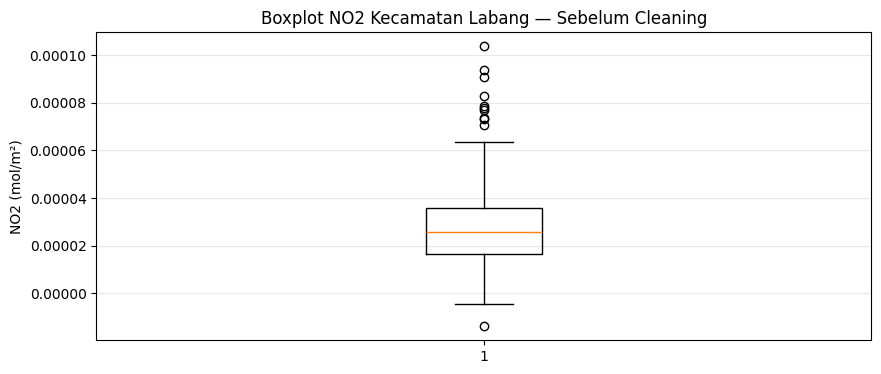

In [16]:
plt.figure(figsize=(10, 4))
plt.boxplot(dfNO2["NO2"].dropna())
plt.title("Boxplot NO2 Kecamatan Labang — Sebelum Cleaning")
plt.ylabel("NO2 (mol/m\u00b2)")
plt.grid(axis="y", alpha=0.3)
plt.show()

### 3.11 Membentuk kalender harian lengkap

Karena analisis bersifat time series harian, tanggal yang **tidak muncul sama sekali** pada data mentah (misalnya karena tidak ada lintasan satelit yang valid) juga harus dianggap sebagai *missing*, bukan hanya baris dengan nilai `NaN`. Oleh karena itu dibuat kalender penuh dari 31-08-2025 sampai 31-08-2026, lalu data di-*reindex* ke kalender tersebut — tanggal yang tidak ada datanya otomatis menjadi `NaN`.


In [17]:
full_dates = pd.date_range(start="2025-08-31", end="2026-08-31", freq="D")

df_clean = (
    dfNO2[["date", "NO2"]]
    .drop_duplicates(subset="date")
    .set_index("date")
    .reindex(full_dates)
)
df_clean.index.name = "date"

print("Jumlah tanggal seharusnya (kalender penuh) :", len(full_dates))
print("Jumlah baris setelah reindex                :", len(df_clean))
print("Jumlah missing setelah reindex               :", int(df_clean['NO2'].isna().sum()))

Jumlah tanggal seharusnya (kalender penuh) : 366
Jumlah baris setelah reindex                : 366
Jumlah missing setelah reindex               : 170


### 3.12 Imputasi missing value dan outlier

**Urutan proses:**

1. Nilai di luar batas IQR (dari poin 3.10) $\rightarrow$ ditandai `NaN`.
2. *Missing values* di **tengah** *time series* $\rightarrow$ diisi dengan **interpolasi linear berbasis waktu** (`interpolate(method="time")`).
3. *Missing values* yang tersisa di **ujung awal/akhir** (tidak bisa diinterpolasi karena tidak ada titik pembanding di salah satu sisi) $\rightarrow$ diisi dengan *forward fill* (`ffill`) lalu *backward fill* (`bfill`).
4. Validasi ulang $\rightarrow$ pastikan tidak ada `NaN` yang tersisa.

**Rumus interpolasi linear** — untuk mengisi titik kosong pada waktu $t$ yang berada di antara dua titik dikenal $(t_1, y_1)$ dan $(t_2, y_2)$:

$$y(t) = y_1 + \frac{t - t_1}{t_2 - t_1} \times (y_2 - y_1)$$

**Contoh perhitungan manual:**  
Andaikan $\text{NO}_2$ pada 10 Januari 2026 $= 3.0 \times 10^{-5}$ dan pada 12 Januari 2026 $= 5.0 \times 10^{-5}$, sedangkan 11 Januari 2026 kosong. Karena $t = 11 \text{ Jan}$ tepat di tengah $t_1 = 10 \text{ Jan}$ dan $t_2 = 12 \text{ Jan}$, maka $\frac{t - t_1}{t_2 - t_1} = \frac{1}{2}$, sehingga:

$$y(11\text{ Jan}) = 3.0 \times 10^{-5} + \frac{1}{2} \times \left(5.0 \times 10^{-5} - 3.0 \times 10^{-5}\right) = 4.0 \times 10^{-5}$$

Ini setara dengan rata-rata sederhana $\frac{y_1 + y_2}{2}$ karena titik kosong berada tepat di tengah selisih waktu satu hari. Jika jarak waktunya tidak simetris, bobot $\frac{t - t_1}{t_2 - t_1}$ akan menyesuaikan secara proporsional — inilah yang membedakan interpolasi *time-based* dari sekadar mengisi rata-rata global.


In [18]:
# Tandai outlier pada data kalender penuh sebagai NaN
clean_outlier_mask = (df_clean["NO2"] < lower_bound) | (df_clean["NO2"] > upper_bound)
n_outliers_in_full_series = int(clean_outlier_mask.sum())

df_clean.loc[clean_outlier_mask, "NO2"] = np.nan
missing_before_imputation = int(df_clean["NO2"].isna().sum())

print("Outlier yang ditandai ulang jadi NaN pada kalender penuh :", n_outliers_in_full_series)
print("Total missing sebelum imputasi (outlier + gap kalender)   :", missing_before_imputation)

# Interpolasi berbasis waktu untuk missing di tengah deret
df_clean["NO2"] = df_clean["NO2"].interpolate(method="time")

# Sisa missing di ujung awal/akhir (tidak bisa diinterpolasi) -> ffill lalu bfill
df_clean["NO2"] = df_clean["NO2"].ffill().bfill()

missing_after_imputation = int(df_clean["NO2"].isna().sum())
print("Missing setelah imputasi                                  :", missing_after_imputation)

Outlier yang ditandai ulang jadi NaN pada kalender penuh : 11
Total missing sebelum imputasi (outlier + gap kalender)   : 181
Missing setelah imputasi                                  : 0


### 3.13 Validasi sebelum ekstraksi TSFEL

Sinyal dianggap layak diproses TSFEL hanya jika **seluruh** syarat berikut terpenuhi:

- jumlah observasi = 366 (sesuai kalender penuh);
- kolom `NO2` bertipe numerik;
- tidak ada `NaN`;
- tidak ada `+inf` / `-inf`;
- tanggal terurut menaik (monotonic increasing).


In [19]:
df_final_signal = df_clean[["NO2"]].copy()

checks = {
    "Tidak ada missing value"   : df_final_signal["NO2"].isna().sum() == 0,
    "Tidak ada nilai +infinity" : np.isposinf(df_final_signal["NO2"]).sum() == 0,
    "Tidak ada nilai -infinity" : np.isneginf(df_final_signal["NO2"]).sum() == 0,
    "Kolom NO2 numerik"         : pd.api.types.is_numeric_dtype(df_final_signal["NO2"]),
    "Jumlah tanggal lengkap"    : len(df_final_signal) == len(full_dates),
    "Tanggal terurut menaik"    : df_final_signal.index.is_monotonic_increasing,
}

for name, result in checks.items():
    print(f"[{'OK' if result else 'GAGAL'}] {name}")

if all(checks.values()):
    print("\nVALIDASI LULUS -> data siap untuk ekstraksi fitur TSFEL.")
else:
    raise ValueError("VALIDASI GAGAL -> periksa kembali tahap deteksi outlier/imputasi sebelum lanjut.")

[OK] Tidak ada missing value
[OK] Tidak ada nilai +infinity
[OK] Tidak ada nilai -infinity
[OK] Kolom NO2 numerik
[OK] Jumlah tanggal lengkap
[OK] Tanggal terurut menaik

VALIDASI LULUS -> data siap untuk ekstraksi fitur TSFEL.


In [20]:
df_final_signal.reset_index().to_csv("NO2_Labang_clean.csv", index=False)

print("File hasil cleaning tersimpan: NO2_Labang_clean.csv")
display(df_final_signal.head())
display(df_final_signal.tail())

colab_files.download("NO2_Labang_clean.csv")
print("Unduhan dimulai: NO2_Labang_clean.csv (data setelah outlier & missing ditangani).")

File hasil cleaning tersimpan: NO2_Labang_clean.csv


,NO2
date,
2025-08-31,9.14127e-06
2025-09-01,1.07454e-05
2025-09-02,5.24885e-06
2025-09-03,1.23937e-05
2025-09-04,1.45782e-05


,NO2
date,
2026-08-27,2.44917e-05
2026-08-28,2.26857e-05
2026-08-29,1.58232e-05
2026-08-30,1.71793e-05
2026-08-31,1.71793e-05


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Unduhan dimulai: NO2_Labang_clean.csv (data setelah outlier & missing ditangani).


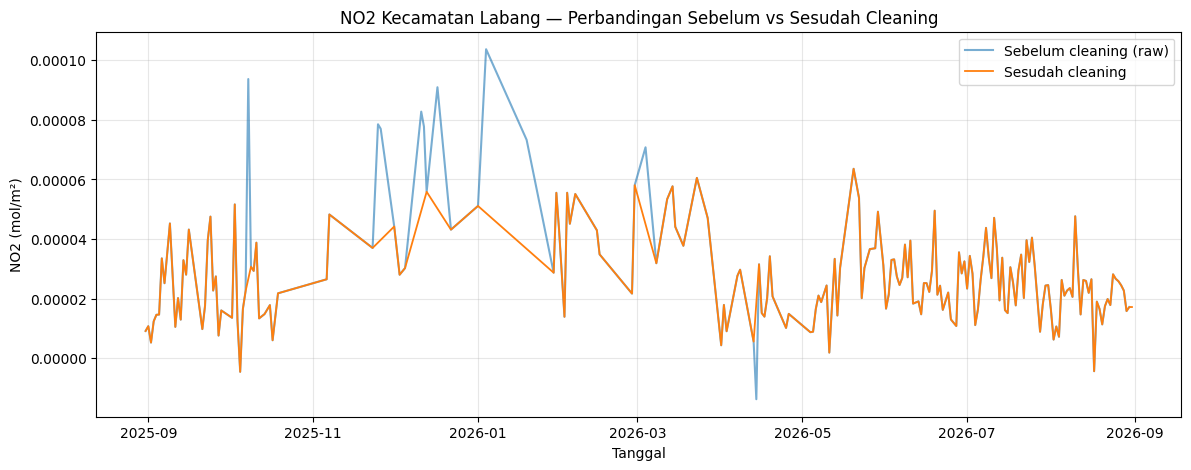

In [21]:
plt.figure(figsize=(14, 5))
plt.plot(dfNO2["date"], dfNO2["NO2"], label="Sebelum cleaning (raw)", alpha=0.6)
plt.plot(df_final_signal.index, df_final_signal["NO2"], label="Sesudah cleaning", linewidth=1.3)
plt.title("NO2 Kecamatan Labang — Perbandingan Sebelum vs Sesudah Cleaning")
plt.xlabel("Tanggal")
plt.ylabel("NO2 (mol/m\u00b2)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 4. Modeling — Ekstraksi 68 Fitur dengan TSFEL

### 4.1 Apa itu TSFEL?

**TSFEL** (*Time Series Feature Extraction Library*) adalah pustaka Python yang menyediakan puluhan fungsi siap pakai untuk mengekstrak fitur numerik dari sebuah sinyal time series — mencakup domain **statistik**, **temporal**, **spektral (frekuensi)**, dan **fraktal/kompleksitas**. Setiap fungsi menerima array 1 dimensi (sinyal) dan mengembalikan satu (atau beberapa) nilai ringkasan.

### 4.2 Mengapa hasilnya hanya 1 baris?

**seluruh 366 nilai NO2 harian sebagai satu sinyal time series tunggal**, bukan 366 baris data independen. Oleh karena itu:

$$
\underbrace{366 \text{ nilai harian}}_{\text{1 sinyal}} \;\xrightarrow{68 \text{ fungsi TSFEL}}\; \underbrace{68 \text{ nilai ringkasan}}_{\text{1 baris} \times \text{68 kolom}}
$$

Parameter `fs` (frekuensi sampling) diset **`fs = 1`** karena satuan waktu antar-observasi adalah **1 hari**, sehingga "frekuensi" pada fitur-fitur spektral (misalnya `spectral_centroid`, `max_frequency`) diinterpretasikan dalam satuan **siklus per hari**, bukan Hz fisik biasa.



In [22]:
import tsfel.feature_extraction.features as tsfel_features

#1. Muat dan bersihkan data
df = df_final_signal.reset_index().copy()
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

target_pollutant = 'NO2'

#FIX: paksa kolom target jadi numerik, nilai yang gagal dikonversi -> NaN
df[target_pollutant] = pd.to_numeric(df[target_pollutant], errors='coerce')

n_missing_before = df[target_pollutant].isna().sum()
print(f"Jumlah nilai non-numerik/kosong yang dikonversi jadi NaN: {n_missing_before}")

Q1 = df[target_pollutant].quantile(0.25)
Q3 = df[target_pollutant].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df.loc[(df[target_pollutant] < lower_bound) | (df[target_pollutant] > upper_bound), target_pollutant] = np.nan

df_clean = df.set_index('date').interpolate(method='time').ffill().bfill()

fs = 1
signal_1d = df_clean[target_pollutant].astype(float).values


FEATURE_LIST = '''abs_energy auc autocorr average_power calc_centroid calc_max calc_mean
calc_median calc_min calc_std calc_var dfa distance ecdf ecdf_percentile ecdf_percentile_count
ecdf_slope entropy fundamental_frequency higuchi_fractal_dimension hist_mode human_range_energy
hurst_exponent interq_range kurtosis lempel_ziv lpcc max_frequency max_power_spectrum
maximum_fractal_length mean_abs_deviation mean_abs_diff mean_diff median_abs_deviation
median_abs_diff median_diff median_frequency mfcc mse negative_turning neighbourhood_peaks
petrosian_fractal_dimension pk_pk_distance positive_turning power_bandwidth rms skewness slope
spectral_centroid spectral_decrease spectral_distance spectral_entropy spectral_kurtosis
spectral_positive_turning spectral_roll_off spectral_roll_on spectral_skewness spectral_slope
spectral_spread spectral_variation spectrogram_mean_coeff sum_abs_diff wavelet_abs_mean
wavelet_energy wavelet_entropy wavelet_std wavelet_var zero_cross'''.split()

print("Jumlah fitur yang diminta:", len(FEATURE_LIST))


def to_scalar(result):
    if isinstance(result, dict) and "values" in result:
        result = result["values"]
    if isinstance(result, (list, tuple, np.ndarray)):
        arr = np.asarray(result, dtype=float)
        return float(np.nanmean(arr))
    return float(result)


def extract_one(fn_name, signal, fs):
    fn = getattr(tsfel_features, fn_name)
    params = inspect.signature(fn).parameters
    if "fs" in params:
        result = fn(signal, fs)
    else:
        result = fn(signal)
    return to_scalar(result)


row = {}
for fn_name in FEATURE_LIST:
    row[fn_name] = extract_one(fn_name, signal_1d, fs)

extracted_features_final = pd.DataFrame([row])

print(f"Berhasil! Jumlah fitur yang dihasilkan untuk {target_pollutant}: {extracted_features_final.shape[1]}")
extracted_features_final.to_csv(f'{target_pollutant}_Labang_TSFEL.csv', index=False)


Jumlah nilai non-numerik/kosong yang dikonversi jadi NaN: 0
Jumlah fitur yang diminta: 68
Berhasil! Jumlah fitur yang dihasilkan untuk NO2: 68


### 4.3 Validasi hasil ekstraksi

Memastikan output benar-benar berjumlah 68 kolom, nama & urutannya identik dengan `FEATURE_LIST`, serta tidak mengandung `NaN` maupun nilai tak-hingga.


In [23]:
expected_features = FEATURE_LIST

print("Shape output extracted_features_final :", extracted_features_final.shape)
print("Jumlah fitur yang diharapkan          :", len(expected_features))

same_order = list(extracted_features_final.columns) == expected_features
same_names = set(extracted_features_final.columns) == set(expected_features)

print("Nama fitur sama dengan FEATURE_LIST ? :", same_names)
print("Urutan fitur sama                    ? :", same_order)
print("Jumlah NaN pada output                :", int(extracted_features_final.isna().sum().sum()))
print("Jumlah nilai infinity pada output      :", int(np.isinf(extracted_features_final.to_numpy(dtype=float)).sum()))

if extracted_features_final.shape[1] != 68:
    raise ValueError("Output BUKAN 68 fitur -- periksa FEATURE_LIST.")
if not same_order:
    raise ValueError("Nama atau urutan fitur berubah dari FEATURE_LIST.")
if extracted_features_final.isna().any().any():
    raise ValueError("Terdapat NaN pada output fitur.")
if np.isinf(extracted_features_final.to_numpy(dtype=float)).any():
    raise ValueError("Terdapat nilai infinity pada output fitur.")

print("\nVALIDASI TSFEL LULUS -- tepat 68 fitur.")

Shape output extracted_features_final : (1, 68)
Jumlah fitur yang diharapkan          : 68
Nama fitur sama dengan FEATURE_LIST ? : True
Urutan fitur sama                    ? : True
Jumlah NaN pada output                : 0
Jumlah nilai infinity pada output      : 0

VALIDASI TSFEL LULUS -- tepat 68 fitur.


### 4.4 Pengelompokan berdasarkan domain resmi TSFEL (Statistical, Temporal, Spectral)
TSFEL sendiri secara resmi membagi seluruh fungsi fiturnya ke dalam **tiga domain utama**. Pembagian inilah yang dipakai di dalam dokumentasi/konfigurasi TSFEL (`cfg_file`)

| Domain | Definisi singkat | Jumlah fitur pada `FEATURE_LIST` |
|---|---|---|
| **Statistical** | Menghitung ciri distribusi nilai sinyal secara keseluruhan (tanpa memperhatikan urutan waktu) — mis. pusat, sebaran, bentuk distribusi | 17 fitur |
| **Temporal** | Menghitung ciri yang bergantung pada **urutan waktu** sinyal — mis. perubahan antar-titik, tren, kompleksitas, titik balik | 24 fitur |
| **Spectral** | Menghitung ciri sinyal setelah ditransformasi ke **domain frekuensi** (melalui FFT/wavelet) — mis. energi pada frekuensi tertentu, bentuk spektrum | 27 fitur |
| **Total** | | **68 fitur** |

**Rincian anggota tiap domain (mengikuti daftar resmi TSFEL):**

**a) Domain Statistical (17 fitur)**
`ecdf`, `ecdf_percentile`, `ecdf_percentile_count`, `ecdf_slope`, `entropy`, `hist_mode`, `interq_range`, `kurtosis`, `calc_max`, `calc_mean`, `mean_abs_deviation`, `calc_median`, `median_abs_deviation`, `calc_min`, `skewness`, `calc_std`, `calc_var`

| No | Fitur                   | Pengertian                                                                                                                                                   |
| -- | ----------------------- | ------------------------------------------------------------------------------------------------------------------------------------------------------------ |
| 1  | `ecdf`                  | **Empirical Cumulative Distribution Function**, yaitu fungsi yang menunjukkan proporsi data yang memiliki nilai kurang dari atau sama dengan nilai tertentu. |
| 2  | `ecdf_percentile`       | Menunjukkan **persentil tertentu** berdasarkan distribusi kumulatif data. Digunakan untuk mengetahui posisi suatu nilai dalam distribusi.                    |
| 3  | `ecdf_percentile_count` | Menghitung **jumlah data** yang berada pada atau di bawah batas persentil tertentu berdasarkan ECDF.                                                         |
| 4  | `ecdf_slope`            | Menggambarkan **kemiringan ECDF**, yang menunjukkan seberapa cepat distribusi kumulatif berubah terhadap nilai data.                                         |
| 5  | `entropy`               | Mengukur **tingkat ketidakpastian atau keragaman** dalam distribusi data. Entropy tinggi berarti data lebih tidak teratur/beragam.                           |
| 6  | `hist_mode`             | Menentukan **modus berdasarkan histogram**, yaitu rentang/bin yang paling banyak memiliki data.                                                              |
| 7  | `interq_range`          | **Interquartile Range (IQR)**, yaitu selisih antara kuartil ketiga (Q3) dan kuartil pertama (Q1). Menggambarkan penyebaran 50% data tengah.                  |
| 8  | `kurtosis`              | Mengukur **keruncingan distribusi data** dan kecenderungan munculnya nilai ekstrem (*outlier*).                                                              |
| 9  | `calc_max`              | Menentukan **nilai maksimum** dalam kumpulan data.                                                                                                           |
| 10 | `calc_mean`             | Menghitung **nilai rata-rata** seluruh data.                                                                                                                 |
| 11 | `mean_abs_deviation`    | Rata-rata **jarak absolut setiap nilai terhadap rata-rata**. Mengukur seberapa menyebar data dari nilai tengahnya.                                           |
| 12 | `calc_median`           | Menentukan **nilai tengah (median)** setelah data diurutkan.                                                                                                 |
| 13 | `median_abs_deviation`  | **Median Absolute Deviation (MAD)**, yaitu median dari jarak absolut data terhadap median. Lebih tahan terhadap *outlier* dibanding standar deviasi.         |
| 14 | `calc_min`              | Menentukan **nilai minimum** dalam kumpulan data.                                                                                                            |
| 15 | `skewness`              | Mengukur **kemencengan distribusi** data. Nilai positif menunjukkan ekor distribusi cenderung ke kanan, sedangkan negatif ke kiri.                           |
| 16 | `calc_std`              | **Standard deviation**, yaitu ukuran seberapa jauh nilai data menyebar dari rata-ratanya.                                                                    |
| 17 | `calc_var`              | **Variance**, yaitu ukuran penyebaran data yang berasal dari kuadrat deviasi terhadap rata-rata.                                                             |


**b) Domain Temporal (24 fitur)**
`abs_energy`, `auc`, `autocorr`, `calc_centroid`, `distance`, `dfa`, `higuchi_fractal_dimension`, `hurst_exponent`, `lempel_ziv`, `maximum_fractal_length`, `mean_abs_diff`, `mean_diff`, `median_abs_diff`, `median_diff`, `negative_turning`, `positive_turning`, `neighbourhood_peaks`, `petrosian_fractal_dimension`, `pk_pk_distance`, `slope`, `sum_abs_diff`, `zero_cross`, `rms`, `mse`

| No | Fitur                         | Pengertian                                                                                                                                     |
| -- | ----------------------------- | ---------------------------------------------------------------------------------------------------------------------------------------------- |
| 1  | `abs_energy`                  | Mengukur **energi absolut sinyal**, umumnya berdasarkan jumlah kuadrat nilai sinyal.                                                           |
| 2  | `auc`                         | **Area Under the Curve**, yaitu luas area di bawah kurva data terhadap waktu.                                                                  |
| 3  | `autocorr`                    | Mengukur **korelasi data dengan dirinya sendiri pada lag tertentu**, sehingga dapat melihat pola berulang.                                     |
| 4  | `calc_centroid`               | Menentukan **titik pusat/centroid distribusi nilai terhadap waktu**, sehingga menunjukkan kecenderungan posisi data dalam suatu rentang waktu. |
| 5  | `distance`                    | Mengukur **jarak/perubahan antar nilai yang berurutan** dalam deret waktu.                                                                     |
| 6  | `dfa`                         | **Detrended Fluctuation Analysis**, digunakan untuk mengetahui **korelasi jangka panjang** atau pola ketergantungan dalam time series.         |
| 7  | `higuchi_fractal_dimension`   | Mengukur **dimensi fraktal menggunakan metode Higuchi**, yang menggambarkan kompleksitas/ketidakaturan sinyal.                                 |
| 8  | `hurst_exponent`              | Mengukur **ketergantungan jangka panjang** pada time series. Nilai berbeda dapat menunjukkan sifat *persistent*, acak, atau *anti-persistent*. |
| 9  | `lempel_ziv`                  | Mengukur **kompleksitas urutan data** berdasarkan banyaknya pola baru yang muncul dalam sinyal.                                                |
| 10 | `maximum_fractal_length`      | Mengukur **panjang/ukuran maksimum struktur fraktal** yang terdapat pada sinyal.                                                               |
| 11 | `mean_abs_diff`               | Rata-rata **nilai absolut perubahan antara dua titik waktu yang berurutan**.                                                                   |
| 12 | `mean_diff`                   | Rata-rata **perubahan nilai antar titik waktu berturut-turut**.                                                                                |
| 13 | `median_abs_diff`             | Median dari **perubahan absolut antar nilai yang berurutan**.                                                                                  |
| 14 | `median_diff`                 | Median dari **perubahan nilai antar titik waktu**.                                                                                             |
| 15 | `negative_turning`            | Menghitung **titik pembalikan arah negatif**, misalnya ketika pola berubah dari naik menjadi turun.                                            |
| 16 | `positive_turning`            | Menghitung **titik pembalikan arah positif**, misalnya ketika pola berubah dari turun menjadi naik.                                            |
| 17 | `neighbourhood_peaks`         | Mengidentifikasi **puncak lokal** berdasarkan nilai tetangga di sekitarnya.                                                                    |
| 18 | `petrosian_fractal_dimension` | Mengukur **kompleksitas sinyal** berdasarkan perubahan/derivatif diskrit pada sinyal.                                                          |
| 19 | `pk_pk_distance`              | Mengukur **jarak atau interval antara puncak dan lembah** (*peak-to-peak*).                                                                    |
| 20 | `slope`                       | Mengukur **kemiringan/tren perubahan data terhadap waktu**.                                                                                    |
| 21 | `sum_abs_diff`                | Jumlah seluruh **perubahan absolut antar nilai berurutan**.                                                                                    |
| 22 | `zero_cross`                  | Menghitung berapa kali sinyal **melewati nilai nol** atau titik referensi tertentu.                                                            |
| 23 | `rms`                         | **Root Mean Square**, yaitu ukuran besarnya amplitudo/energi efektif sinyal.                                                                   |
| 24 | `mse`                         | **Mean Squared Error**, yaitu rata-rata kuadrat kesalahan/perbedaan antara nilai aktual dan nilai pembanding/prediksi.                         |


**c) Domain Spectral (27 fitur)**
`average_power`, `fundamental_frequency`, `human_range_energy`, `lpcc`, `mfcc`, `max_power_spectrum`, `max_frequency`, `median_frequency`, `power_bandwidth`, `spectral_centroid`, `spectral_decrease`, `spectral_distance`, `spectral_entropy`, `spectral_kurtosis`, `spectral_positive_turning`, `spectral_roll_off`, `spectral_roll_on`, `spectral_skewness`, `spectral_slope`, `spectral_spread`, `spectral_variation`, `spectrogram_mean_coeff`, `wavelet_abs_mean`, `wavelet_energy`, `wavelet_entropy`, `wavelet_std`, `wavelet_var`

| No | Fitur                       | Pengertian                                                                                                                                               |
| -- | --------------------------- | -------------------------------------------------------------------------------------------------------------------------------------------------------- |
| 1  | `average_power`             | Rata-rata **daya/energi sinyal** pada spektrum frekuensi.                                                                                                |
| 2  | `fundamental_frequency`     | **Frekuensi dasar**, yaitu frekuensi utama yang menjadi komponen dasar suatu sinyal.                                                                     |
| 3  | `human_range_energy`        | Energi pada **rentang frekuensi tertentu yang didefinisikan sebagai rentang manusia**; relevansinya bergantung pada jenis sinyal yang dianalisis.        |
| 4  | `lpcc`                      | **Linear Prediction Cepstral Coefficients**, fitur yang menggambarkan karakteristik spektral berdasarkan analisis prediksi linear.                       |
| 5  | `mfcc`                      | **Mel-Frequency Cepstral Coefficients**, fitur spektral yang banyak digunakan untuk menggambarkan karakteristik frekuensi, terutama pada analisis suara. |
| 6  | `max_power_spectrum`        | Nilai **daya maksimum** yang ditemukan dalam spektrum frekuensi.                                                                                         |
| 7  | `max_frequency`             | Frekuensi yang berkaitan dengan **komponen spektral maksimum** atau frekuensi tertinggi yang dipertimbangkan oleh fitur.                                 |
| 8  | `median_frequency`          | Frekuensi yang membagi **total energi/daya spektrum menjadi dua bagian yang sama**.                                                                      |
| 9  | `power_bandwidth`           | Rentang frekuensi yang menunjukkan **sebaran daya utama** dalam spektrum.                                                                                |
| 10 | `spectral_centroid`         | Menentukan **pusat massa spektrum**, sehingga menggambarkan frekuensi dominan secara rata-rata.                                                          |
| 11 | `spectral_decrease`         | Mengukur **penurunan energi spektral** seiring meningkatnya frekuensi.                                                                                   |
| 12 | `spectral_distance`         | Mengukur **jarak/perbedaan antara distribusi spektral**, bergantung pada definisi implementasi fitur.                                                    |
| 13 | `spectral_entropy`          | Mengukur **ketidakaturan distribusi energi pada spektrum frekuensi**.                                                                                    |
| 14 | `spectral_kurtosis`         | Mengukur **keruncingan distribusi energi pada spektrum frekuensi**.                                                                                      |
| 15 | `spectral_positive_turning` | Mengidentifikasi **titik pembalikan positif** pada bentuk spektrum.                                                                                      |
| 16 | `spectral_roll_off`         | Frekuensi di bawahnya terdapat **persentase tertentu dari total energi spektrum**, sering digunakan untuk mengetahui batas frekuensi utama.              |
| 17 | `spectral_roll_on`          | Frekuensi ketika **energi spektral mulai mencapai persentase tertentu** dari total energi.                                                               |
| 18 | `spectral_skewness`         | Mengukur **kemencengan distribusi energi spektrum**.                                                                                                     |
| 19 | `spectral_slope`            | Mengukur **kemiringan perubahan energi terhadap frekuensi**.                                                                                             |
| 20 | `spectral_spread`           | Mengukur **seberapa lebar penyebaran energi di sekitar spectral centroid**.                                                                              |
| 21 | `spectral_variation`        | Mengukur **perubahan karakteristik spektrum**, biasanya antarsegmen atau antarwaktu.                                                                     |
| 22 | `spectrogram_mean_coeff`    | Rata-rata **koefisien dari spectrogram**, yaitu representasi perubahan spektrum terhadap waktu.                                                          |
| 23 | `wavelet_abs_mean`          | Rata-rata **nilai absolut koefisien wavelet**.                                                                                                           |
| 24 | `wavelet_energy`            | Mengukur **energi sinyal berdasarkan koefisien wavelet** pada skala tertentu.                                                                            |
| 25 | `wavelet_entropy`           | Mengukur **ketidakaturan distribusi energi pada representasi wavelet**.                                                                                  |
| 26 | `wavelet_std`               | **Standar deviasi koefisien wavelet**, menunjukkan penyebaran nilainya.                                                                                  |
| 27 | `wavelet_var`               | **Varians koefisien wavelet**, menunjukkan tingkat variasi energi/koefisien pada representasi wavelet.                                                   |


> **Interpretasi untuk kasus NO2 Labang:** karena sinyal berupa 1 nilai per hari (`fs = 1`), domain **Statistical** menjawab pertanyaan *"secara umum bagaimana sebaran NO2 selama setahun?"*, domain **Temporal** menjawab *"seberapa cepat/kompleks NO2 berubah dari hari ke hari?"*, dan domain **Spectral** menjawab *"apakah ada pola siklik/musiman (mis. mingguan, bulanan) yang berulang?"* — ketiganya saling melengkapi, bukan saling menggantikan.


### Perhitungan manual 68 fitur TSFEL

### A. Statistical — 17 Fitur

| No | Fitur | Cara Perhitungan Manual & Keterangan Rumus | Penjelasan |
|---:|---|---|---|
| 1 | `ecdf` | $F_n(z) = \frac{1}{n} \sum_{i=1}^{n} I(x_i \le z)$<br><br>**Keterangan:**<br>• $n$: jumlah total observasi/data.<br>• $I(\cdot)$: fungsi indikator, bernilai $1$ jika kondisi $x_i \le z$ terpenuhi, dan $0$ jika tidak.<br>• $z$: titik nilai batas yang dievaluasi. | Hitung berapa nilai $\text{NO}_2$ yang lebih kecil/sama dengan nilai $z$, lalu bagi dengan jumlah observasi. Hasil menunjukkan proporsi data sampai titik $z$. |
| 2 | `ecdf_percentile` | Urutkan data $x_{(1)} \le \dots \le x_{(n)}$.<br>Posisi persentil $p$: $L = (n-1)p + 1$<br><br>**Keterangan:**<br>• $x_{(i)}$: data ke-$i$ setelah diurutkan.<br>• $p$: nilai persentil yang dicari ($0 \le p \le 1$, contoh $0{,}25$ untuk $P_{25}$).<br>• $L$: indeks/posisi urutan nilai persentil. | Digunakan untuk mengetahui nilai $\text{NO}_2$ yang menjadi batas persentil tertentu, misalnya $P_{25}$, $P_{50}$, atau $P_{75}$. |
| 3 | `ecdf_percentile_count` | Cari nilai batas $q_p$ dari persentil $p$, lalu hitung:<br>$C = \sum_{i=1}^{n} I(x_i \le q_p)$<br><br>**Keterangan:**<br>• $q_p$: nilai ambang batas pada persentil ke-$p$.<br>• $C$: jumlah observasi yang nilainya $\le q_p$. | Menunjukkan jumlah observasi yang berada sampai batas persentil tersebut. |
| 4 | `ecdf_slope` | $s = \frac{F_2 - F_1}{z_2 - z_1}$<br><br>**Keterangan:**<br>• $F_1, F_2$: nilai ECDF (proporsi kumulatif) pada titik $z_1$ dan $z_2$.<br>• $z_1, z_2$: dua titik nilai observasi yang dibandingkan.<br>• $s$: kemiringan (*slope*) ECDF. | Mengukur seberapa cepat proporsi kumulatif berubah ketika nilai $\text{NO}_2$ berubah. |
| 5 | `entropy` | $H = -\sum_{j} p_j \log_2 p_j$<br><br>**Keterangan:**<br>• $p_j$: probabilitas kemunculan data pada kelompok/interval ke-$j$.<br>• $\log_2$: logaritma basis 2.<br>• $H$: nilai *entropy* (kelimpahan/keragaman). | Semakin merata/beragam distribusi nilai $\text{NO}_2$, semakin tinggi *entropy*. |
| 6 | `hist_mode` | Bagi rentang nilai menjadi beberapa *bin* ($B_1, B_2, \dots$), hitung frekuensi $f_j = \text{count}(x_i \in B_j)$. Pilih $B_{\text{mode}}$ dengan $f_j$ tertinggi.<br><br>**Keterangan:**<br>• $B_j$: interval/kelompok rentang nilai ke-$j$.<br>• $f_j$: frekuensi data pada *bin* ke-$j$. | Menentukan rentang nilai $\text{NO}_2$ yang paling sering muncul. |
| 7 | `interq_range` | $\text{IQR} = Q_3 - Q_1$<br><br>**Keterangan:**<br>• $Q_1$: kuartil pertama / persentil ke-25 ($P_{25}$).<br>• $Q_3$: kuartil ketiga / persentil ke-75 ($P_{75}$).<br>• $\text{IQR}$: rentang antarkuartil. | Mengukur sebaran 50% data $\text{NO}_2$ bagian tengah dan relatif tahan terhadap *outlier*. |
| 8 | `kurtosis` | $\text{Excess Kurtosis} = \frac{m_4}{m_2^2} - 3$<br><br>**Keterangan:**<br>• $m_k = \frac{1}{n} \sum_{i=1}^{n} (x_i - \bar{x})^k$: momen terpusat ke-$k$.<br>• $m_2$: varians sampel ($k=2$).<br>• $m_4$: momen terpusat ke-4 ($k=4$). | Menunjukkan keruncingan distribusi dan kecenderungan adanya nilai ekstrem (*outlier*). |
| 9 | `calc_max` | $x_{\max} = \max(x_1, x_2, \dots, x_n)$<br><br>**Keterangan:**<br>• $x_i$: nilai observasi ke-$i$.<br>• $\max(\cdot)$: fungsi untuk mengambil nilai tertinggi. | Ambil nilai $\text{NO}_2$ paling tinggi selama periode pengamatan. |
| 10 | `calc_mean` | $\bar{x} = \frac{1}{n} \sum_{i=1}^{n} x_i$<br><br>**Keterangan:**<br>• $\bar{x}$: nilai rata-rata (mean).<br>• $\sum x_i$: jumlah seluruh nilai data.<br>• $n$: jumlah total hari/observasi (misal 366). | Jumlahkan seluruh $\text{NO}_2$ lalu bagi 366; menghasilkan rata-rata $\text{NO}_2$ selama periode analisis. |
| 11 | `mean_abs_deviation` | $\text{MAD}_{\text{mean}} = \frac{1}{n} \sum_{i=1}^{n} \vert{}x_i - \bar{x}\vert{}$<br><br>**Keterangan:**<br>• $\vert{}x_i - \bar{x}\vert{}$: jarak absolut nilai data ke-$i$ terhadap rata-rata.<br>• $\text{MAD}_{\text{mean}}$: rata-rata penyimpangan absolut. | Mengukur rata-rata jarak absolut setiap nilai $\text{NO}_2$ dari rata-ratanya. |
| 12 | `calc_median` | Jika $n$ ganjil: $\tilde{x} = x_{\left(\frac{n+1}{2}\right)}$<br>Jika $n$ genap: $\tilde{x} = \frac{x_{\left(\frac{n}{2}\right)} + x_{\left(\frac{n}{2}+1\right)}}{2}$<br><br>**Keterangan:**<br>• $\tilde{x}$: nilai median (titik tengah data terurut). | Menentukan nilai tengah $\text{NO}_2$ dan lebih tahan terhadap nilai ekstrem daripada *mean*. |
| 13 | `median_abs_deviation` | $\text{MAD}_{\text{median}} = \text{median}(\vert{}x_i - \tilde{x}\vert{})$<br><br>**Keterangan:**<br>• $\tilde{x}$: nilai median dari dataset asli.<br>• $\vert{}x_i - \tilde{x}\vert{}$: deviasi absolut dari tiap data terhadap median. | Mengukur penyimpangan tipikal dari median dan relatif *robust* terhadap *outlier*. |
| 14 | `calc_min` | $x_{\min} = \min(x_1, x_2, \dots, x_n)$<br><br>**Keterangan:**<br>• $\min(\cdot)$: fungsi untuk mengambil nilai terendah. | Ambil nilai $\text{NO}_2$ paling rendah selama periode pengamatan. |
| 15 | `skewness` | $Sk = \frac{m_3}{m_2^{3/2}}$<br><br>**Keterangan:**<br>• $m_3 = \frac{1}{n} \sum_{i=1}^{n} (x_i - \bar{x})^3$: momen terpusat ke-3.<br>• $m_2$: momen terpusat ke-2 (varians).<br>• $Sk$: koefisien kemencengan. | Menunjukkan kemencengan distribusi $\text{NO}_2$ ke kanan (positif) atau ke kiri (negatif). |
| 16 | `calc_std` | $\sigma = \sqrt{\frac{1}{n} \sum_{i=1}^{n} (x_i - \bar{x})^2}$<br><br>**Keterangan:**<br>• $\sigma$: standar deviasi.<br>• Akar kuadrat dari nilai varians ($\sigma^2$). | Akar *variance*; semakin besar nilainya, semakin besar penyebaran $\text{NO}_2$ dari rata-rata. |
| 17 | `calc_var` | $\sigma^2 = \frac{1}{n} \sum_{i=1}^{n} (x_i - \bar{x})^2$<br><br>**Keterangan:**<br>• $\sigma^2$: varians populasi/sampel.<br>• $(x_i - \bar{x})^2$: kuadrat selisih tiap data terhadap rata-rata. | Mengukur tingkat variasi nilai $\text{NO}_2$ terhadap rata-ratanya. |

**Contoh hitung Statistical sederhana:** Jika lima nilai contoh adalah $2, 4, 4, 5, 7$, maka:
* $\text{Mean } (\bar{x}) = \frac{2 + 4 + 4 + 5 + 7}{5} = 4{,}4$
* $\text{Maksimum } (x_{\max}) = 7$
* $\text{Minimum } (x_{\min}) = 2$
* $\text{IQR} = Q_3 - Q_1 = 5 - 4 = 1$

### B. Temporal — 24 Fitur

| No | Fitur | Cara Perhitungan Manual & Keterangan Rumus | Penjelasan |
|---:|---|---|---|
| 1 | `abs_energy` | $E = \sum_{i=1}^{n} x_i^2$<br><br>**Keterangan:**<br>• $n$: jumlah total observasi/data.<br>• $x_i$: nilai observasi $\text{NO}_2$ pada hari ke-$i$.<br>• $E$: total energi sinyal. | Mengkuadratkan setiap nilai $\text{NO}_2$ lalu menjumlahkannya; menggambarkan besarnya energi total sinyal time series. |
| 2 | `auc` | $\text{AUC} \approx \sum_{i=1}^{n-1} \frac{x_i + x_{i+1}}{2} \Delta t$<br><br>**Keterangan:**<br>• $x_i, x_{i+1}$: nilai data pada dua hari berurutan.<br>• $\Delta t$: selisih/jarak waktu antar data (untuk data harian, $\Delta t = 1$). | Menghitung luas area di bawah kurva $\text{NO}_2$ terhadap waktu menggunakan metode trapesium. |
| 3 | `autocorr` | $r_1 = \frac{\sum_{i=1}^{n-1} (x_i - \bar{x}_1)(x_{i+1} - \bar{x}_2)}{\sqrt{\sum_{i=1}^{n-1}(x_i - \bar{x}_1)^2 \sum_{i=1}^{n-1}(x_{i+1} - \bar{x}_2)^2}}$<br><br>**Keterangan:**<br>• $r_1$: korelasi diri (*autocorrelation*) untuk $lag = 1$.<br>• $\bar{x}_1, \bar{x}_2$: rata-rata dari sub-deret $x_1 \dots x_{n-1}$ dan $x_2 \dots x_n$. | Menilai apakah nilai $\text{NO}_2$ hari ini berkaitan/berkorelasi langsung dengan nilai pada hari berikutnya. |
| 4 | `calc_centroid` | $C = \frac{\sum_{i=1}^{n} t_i x_i}{\sum_{i=1}^{n} x_i}$<br><br>**Keterangan:**<br>• $t_i$: indeks/waktu data ke-$i$ ($t_1=1, t_2=2, \dots$).<br>• $x_i$: nilai konsentrasi $\text{NO}_2$ pada waktu $t_i$.<br>• $C$: titik pusat massa sinyal. | Menunjukkan pusat massa sinyal terhadap indeks waktu. Jika nilainya makin besar, bobot konsentrasi tinggi lebih terkonsentrasi di akhir periode. |
| 5 | `distance` | $D = \sum_{i=2}^{n} \vert{}x_i - x_{i-1}\vert{}$<br><br>**Keterangan:**<br>• $\vert{}x_i - x_{i-1}\vert{}$: selisih absolut nilai antar dua hari berurutan.<br>• $D$: total lintasan/jarak pergerakan sinyal. | Menggambarkan akumulasi total perubahan lintasan nilai $\text{NO}_2$ sepanjang urutan waktu. |
| 6 | `dfa` | $Y(k) = \sum_{i=1}^{k} (x_i - \bar{x})$<br>$F(s) = \sqrt{\frac{1}{N} \sum_{k=1}^{N} \left( Y(k) - Y_s(k) \right)^2}$<br>Estimasi slope $\alpha$ dari $\log F(s)$ vs $\log s$<br><br>**Keterangan:**<br>• $Y(k)$: profil kumulatif terpusat.<br>• $Y_s(k)$: tren lokal pada *window* ukuran $s$.<br>• $F(s)$: fluktuasi rata-rata.<br>• $\alpha$: eksponen DFA (*Detrended Fluctuation Analysis*). | Mengukur ketergantungan atau korelasi fluktuasi jangka panjang pada *time series* setelah membuang tren lokal. |
| 7 | `higuchi_fractal_dimension` | $L(m, k) = \frac{\sum_{i=1}^{\lfloor\frac{n-m}{k}\rfloor} \vert{}x_{m+ik} - x_{m+(i-1)k}\vert{} \cdot (n-1)}{\lfloor\frac{n-m}{k}\rfloor \cdot k}$<br>Estimasi slope dari $\log L(k)$ vs $\log(1/k)$<br><br>**Keterangan:**<br>• $k$: skala/interval waktu.<br>• $m$: waktu awal ($1, 2, \dots, k$).<br>• $L(k)$: rata-rata panjang kurva pada skala $k$. | Mengukur tingkat kerumitan dan fraktalitas bentuk geometris dari kurva sinyal $\text{NO}_2$. |
| 8 | `hurst_exponent` | $H$: estimasi slope dari $\log\left(\frac{R}{S}\right)_n$ vs $\log n$<br><br>**Keterangan:**<br>• $R$: rentang akumulasi deviasi (*rescaled range*).<br>• $S$: standar deviasi sampel.<br>• $n$: ukuran sub-interval.<br>• $H$: eksponen Hurst ($0 < H < 1$). | Mengukur kecenderungan tren jangka panjang: $H > 0{,}5$ (*persistent/trending*), $H = 0{,}5$ (*random walk*), dan $H < 0{,}5$ (*anti-persistent*). |
| 9 | `lempel_ziv` | Konversi $x_i$ menjadi biner: $b_i = 1$ jika $x_i \ge \tilde{x}$, else $0$.<br>$C_{\text{LZ}}$ = jumlah substring/pola unik baru.<br><br>**Keterangan:**<br>• $\tilde{x}$: nilai median sinyal.<br>• $b_i$: deret biner masukan.<br>• $C_{\text{LZ}}$: jumlah kompleksitas Lempel-Ziv. | Menilai tingkat keacakan dan pola unik dalam urutan waktu; semakin banyak pola baru, sinyal semakin kompleks. |
| 10 | `maximum_fractal_length` | $L_{\max} = \max_k L(k)$<br><br>**Keterangan:**<br>• $L(k)$: panjang kurva fraktal yang dihitung pada berbagai skala $k$.<br>• $L_{\max}$: nilai panjang fraktal terbesar. | Menunjukkan nilai panjang maksimum dari struktur fraktal sinyal yang terdeteksi. |
| 11 | `mean_abs_diff` | $D_{\text{mean}} = \frac{1}{n-1} \sum_{i=2}^{n} \vert{}x_i - x_{i-1}\vert{}$<br><br>**Keterangan:**<br>• $\vert{}x_i - x_{i-1}\vert{}$: besarnya fluktuasi harian tanpa memperhitungkan arah.<br>• $n-1$: jumlah pasangan hari yang berdampingan. | Rata-rata besarnya perubahan/fluktuasi harian konsentrasi $\text{NO}_2$ dari satu hari ke hari berikutnya. |
| 12 | `mean_diff` | $D_{\text{trend}} = \frac{1}{n-1} \sum_{i=2}^{n} (x_i - x_{i-1})$<br><br>**Keterangan:**<br>• $(x_i - x_{i-1})$: selisih nilai harian yang memperhitungkan arah naik ($+$) atau turun ($-$). | Rata-rata perubahan harian dengan mempertimbangkan arah tren (neto kenaikan/penurunan). |
| 13 | `median_abs_diff` | $d_i = \vert{}x_i - x_{i-1}\vert{}, \quad \text{untuk } i = 2 \dots n$<br>$\text{MAD}_{\text{diff}} = \text{median}(d_2, d_3, \dots, d_n)$<br><br>**Keterangan:**<br>• $d_i$: deret selisih absolut antarhari.<br>• $\text{median}(\cdot)$: nilai tengah dari deret $d_i$ yang diurutkan. | Mengukur nilai perubahan harian absolut yang tipikal dan tidak gampang terpengaruh oleh lonjakan ekstrem tunggal. |
| 14 | `median_diff` | $d_i = x_i - x_{i-1}, \quad \text{untuk } i = 2 \dots n$<br>$\text{Med}_{\text{diff}} = \text{median}(d_2, d_3, \dots, d_n)$<br><br>**Keterangan:**<br>• $d_i$: deret selisih harian (bisa bernilai positif/negatif). | Nilai tengah dari seluruh perubahan harian yang menunjukkan tren perubahan yang paling umum terjadi. |
| 15 | `negative_turning` | $P_{\text{neg}} = \sum_{i=2}^{n-1} I(x_{i-1} < x_i \text{ dan } x_i > x_{i+1})$<br><br>**Keterangan:**<br>• $I(\cdot)$: fungsi indikator bernilai $1$ jika pola terpenuhi.<br>• Pola: data naik lalu turun (membentuk puncak). | Menghitung banyaknya titik balik puncak (*local maximum*) tempat arah sinyal berbalik dari naik menjadi turun. |
| 16 | `positive_turning` | $P_{\text{pos}} = \sum_{i=2}^{n-1} I(x_{i-1} > x_i \text{ dan } x_i < x_{i+1})$<br><br>**Keterangan:**<br>• Pola: data turun lalu naik (membentuk lembah). | Menghitung banyaknya titik balik lembah (*local minimum*) tempat arah sinyal berbalik dari turun menjadi naik. |
| 17 | `neighbourhood_peaks` | $N_{\text{peak}} = \sum_{i=1+w}^{n-w} I(x_i = \max(x_{i-w \dots i+w}))$<br><br>**Keterangan:**<br>• $w$: jendela/jarak tetangga kanan-kiri yang ditentukan.<br>• $N_{\text{peak}}$: jumlah puncak lokal. | Menghitung banyaknya puncak lokal yang nilainya paling tinggi dibanding tetangga di sekitarnya pada interval tertentu. |
| 18 | `petrosian_fractal_dimension` | $D_{\text{petrosian}} = \frac{\log_{10} n}{\log_{10} n + \log_{10} \left( \frac{n}{n + 0{,}4 \cdot N_\Delta} \right)}$<br><br>**Keterangan:**<br>• $n$: jumlah titik data.<br>• $N_\Delta$: jumlah perubahan tanda pada turunan diskrit $(x_{i+1} - x_i)$. | Mengukur dimensi fraktal sinyal secara cepat berdasarkan frekuensi pergantian arah pergerakan grafik. |
| 19 | `pk_pk_distance` | $D_{\text{pp}} = \max(x) - \min(x)$<br><br>**Keterangan:**<br>• $\max(x)$: nilai puncak tertinggi sinyal.<br>• $\min(x)$: nilai lembah terendah sinyal. | Mengukur rentang total amplitudo dari titik puncak tertinggi ke titik terendah (*peak-to-peak*). |
| 20 | `slope` | $b = \frac{n \sum (t_i x_i) - (\sum t_i)(\sum x_i)}{n \sum t_i^2 - (\sum t_i)^2}$<br><br>**Keterangan:**<br>• $t_i$: indeks waktu harian ($t = 0, 1, \dots, n-1$).<br>• $b$: koefisien kemiringan (*slope*) regresi linier. | Menunjukkan laju dan arah kecenderungan tren linier konsentrasi $\text{NO}_2$ selama periode pengamatan. |
| 21 | `sum_abs_diff` | $D_{\text{sum}} = \sum_{i=2}^{n} \vert{}x_i - x_{i-1}\vert{}$<br><br>**Keterangan:**<br>• $\vert{}x_i - x_{i-1}\vert{}$: selisih absolut nilai antar dua hari berurutan. | Menjumlahkan seluruh total variasi perubahan absolut harian secara keseluruhan. |
| 22 | `zero_cross` | $z_i = x_i - \bar{x}$<br>$\text{ZC} = \sum_{i=2}^{n} I(z_{i-1} \cdot z_i < 0)$<br><br>**Keterangan:**<br>• $z_i$: nilai data setelah dikurangi rata-ratanya (*mean-centered*).<br>• $z_{i-1} \cdot z_i < 0$: kondisi terjadi perpotongan/perubahan tanda. | Menghitung seberapa sering kurva sinyal memotong garis rata-ratanya. |
| 23 | `rms` | $\text{RMS} = \sqrt{\frac{1}{n} \sum_{i=1}^{n} x_i^2} = \sqrt{\frac{E}{n}}$<br><br>**Keterangan:**<br>• $E$: nilai `abs_energy`.<br>• $n$: jumlah sampel data. | Mengukur tingkat besaran atau nilai efektif (*Root Mean Square*) dari amplitudo sinyal. |
| 24 | `mse` | $\text{MSE} = \frac{1}{n} \sum_{i=1}^{n} (x_i - \hat{x}_i)^2$<br><br>**Keterangan:**<br>• $\hat{x}_i$: nilai referensi/prediksi/baseline pada waktu ke-$i$.<br>• $(x_i - \hat{x}_i)^2$: kuadrat selisih error. | Mengukur rata-rata kuadrat kesalahan antara sinyal asli terhadap baseline/nilai pembandingnya. |

**Contoh hitung Temporal:** Jika $x = \{2, 4, 6, 5, 8\}$ ($n = 5$), maka selisih absolut antarhari berdampingan adalah:
* $d_2 = \vert{}4 - 2\vert{} = 2$
* $d_3 = \vert{}6 - 4\vert{} = 2$
* $d_4 = \vert{}5 - 6\vert{} = 1$
* $d_5 = \vert{}8 - 5\vert{} = 3$

Maka:
* `sum_abs_diff` $= 2 + 2 + 1 + 3 = 8$
* `mean_abs_diff` $= \frac{8}{5 - 1} = \frac{8}{4} = 2$
* `rms` $= \sqrt{\frac{2^2 + 4^2 + 6^2 + 5^2 + 8^2}{5}} = \sqrt{\frac{4 + 16 + 36 + 25 + 64}{5}} = \sqrt{\frac{145}{5}} = \sqrt{29} \approx 5{,}385$

### C. Spectral — 27 Fitur

Data *time series* dipandang sebagai sinyal dan ditransformasikan ke domain frekuensi:
$$x(t) \xrightarrow{\text{FFT/transformasi}} X(f)$$

Power spektrum ditulis secara umum sebagai:
$$P(f) = \vert{}X(f)\vert{}^2$$

Untuk data harian dengan $f_s = 1$, frekuensi dinyatakan sebagai **siklus per hari**.

| No | Fitur | Cara Perhitungan Manual & Keterangan Rumus | Penjelasan |
|---:|---|---|---|
| 1 | `average_power` | $P_{\text{avg}} = \frac{1}{K} \sum_{k=1}^{K} P_k$<br><br>**Keterangan:**<br>• $K$: total jumlah komponen frekuensi.<br>• $P_k = \vert{}X_k\vert{}^2$: daya (*power*) pada komponen frekuensi ke-$k$.<br>• $P_{\text{avg}}$: rata-rata daya spektral. | Mengukur rata-rata daya yang tersebar pada seluruh komponen frekuensi sinyal. |
| 2 | `fundamental_frequency` | $f_0 = k_{\text{peak}} \cdot \frac{f_s}{N}$<br><br>**Keterangan:**<br>• $k_{\text{peak}}$: indeks frekuensi dengan amplitudo/daya dominan.<br>• $f_s$: frekuensi sampling ($1 \text{ data/hari}$).<br>• $N$: jumlah titik data ($366$). | Menunjukkan frekuensi dasar atau siklus periodik paling utama yang mendominasi fluktuasi konsentrasi $\text{NO}_2$. |
| 3 | `human_range_energy` | $E_{\text{range}} = \sum_{f \in \text{range}} P(f)$<br><br>**Keterangan:**<br>• $\text{range}$: rentang pita frekuensi spesifik yang didefinisikan.<br>• $P(f)$: daya spektral pada frekuensi $f$. | Menghitung akumulasi energi pada pita frekuensi tertentu. Relevansinya disesuaikan dengan rentang siklus $\text{NO}_2$. |
| 4 | `lpcc` | Terapkan *Windowing* $\rightarrow$ Model LPC: $x_t \approx \sum a_i x_{t-i}$ $\rightarrow$ konversi $a_i$ ke koefisien *cepstral* $c_m$.<br><br>**Keterangan:**<br>• $a_i$: koefisien *Linear Predictive Coding* (LPC).<br>• $c_m$: koefisien *Linear Prediction Cepstral Coefficients* (LPCC). | Menghasilkan koefisien yang menggambarkan amplop spektral sinyal menggunakan pemodelan autoregresif. |
| 5 | `mfcc` | FFT $\rightarrow$ $P(f)$ $\rightarrow$ Filter Bank Skala Mel $\rightarrow$ Log Energy $\rightarrow$ Discrete Cosine Transform (DCT).<br><br>**Keterangan:**<br>• MFCC: *Mel-Frequency Cepstral Coefficients*.<br>• Mel Filter: penapis frekuensi berbobot perseptual visual/audio. | Ekstraksi fitur spektral berbasis filter skala Mel; menunjukkan pola bentuk spektrum $\text{NO}_2$. |
| 6 | `max_power_spectrum` | $P_{\max} = \max_k P_k$<br><br>**Keterangan:**<br>• $P_k$: daya spektral pada komponen frekuensi ke-$k$.<br>• $P_{\max}$: nilai daya spektral tertinggi. | Mengambil nilai daya spektral puncak (terbesar) dari seluruh komponen frekuensi. |
| 7 | `max_frequency` | $f_{\max} = \arg\max_{f_k} P(f_k)$<br><br>**Keterangan:**<br>• $P(f_k)$: daya spektral frekuensi $f_k$.<br>• $f_{\max}$: komponen frekuensi yang memiliki daya paling besar. | Menentukan nilai frekuensi yang berasosiasi dengan komponen energi spektral tertinggi. |
| 8 | `median_frequency` | Cari $f_m$ sehingga:<br>$\sum_{k=1}^{m} P_k = 0{,}5 \sum_{k=1}^{K} P_k$<br><br>**Keterangan:**<br>• $f_m$: frekuensi median spektral.<br>• $\sum P_k$: total daya spektrum keseluruhan. | Membagi total energi spektrum menjadi dua bagian yang sama besar (50% di bawah $f_m$, 50% di atas $f_m$). |
| 9 | `power_bandwidth` | $\text{BW} = f_{\text{high}} - f_{\text{low}}$<br><br>**Keterangan:**<br>• $f_{\text{high}}, f_{\text{low}}$: batas frekuensi atas dan bawah tempat sebagian besar daya berada (misal ambang $-3\text{ dB}$). | Mengukur lebar rentang frekuensi tempat energi/daya utama sinyal $\text{NO}_2$ terdistribusi. |
| 10 | `spectral_centroid` | $\text{SC} = \frac{\sum_{k=1}^{K} f_k P_k}{\sum_{k=1}^{K} P_k}$<br><br>**Keterangan:**<br>• $f_k$: nilai frekuensi ke-$k$.<br>• $P_k$: daya spektral pada frekuensi $f_k$.<br>• $\text{SC}$: titik pusat massa spektrum. | Menunjukkan pusat distribusi energi spektral; semakin tinggi nilainya, energi relatif lebih bergeser ke frekuensi tinggi. |
| 11 | `spectral_decrease` | $\text{SD} = \frac{1}{\sum_{k=2}^{K} P_k} \sum_{k=2}^{K} \frac{P_k - P_1}{k - 1}$<br><br>**Keterangan:**<br>• $P_1$: daya pada komponen frekuensi pertama (DC/paling rendah).<br>• $k$: indeks/urutan frekuensi. | Menilai seberapa cepat daya spektral mengalami penurunan seiring meningkatnya nilai frekuensi. |
| 12 | `spectral_distance` | $d(P, Q) = \sqrt{\sum_{k=1}^{K} (P_k - Q_k)^2}$<br><br>**Keterangan:**<br>• $P_k, Q_k$: dua vektor distribusi spektral yang dibandingkan (misal antarsegmen/frame). | Mengukur tingkat perbedaan/jarak antara dua representasi distribusi daya spektral. |
| 13 | `spectral_entropy` | $p_k = \frac{P_k}{\sum P_k}$<br>$H_{\text{spec}} = -\sum_{k=1}^{K} p_k \log_2 p_k$<br><br>**Keterangan:**<br>• $p_k$: probabilitas/proporsi daya pada frekuensi ke-$k$.<br>• $H_{\text{spec}}$: nilai *entropy* spektral. | Mengukur tingkat keacakan/penyebaran energi: nilai tinggi berarti energi tersebar merata di semua frekuensi, nilai rendah berarti terfokus pada beberapa frekuensi saja. |
| 14 | `spectral_kurtosis` | $K_{\text{spec}} = \frac{\sum P_k (f_k - \text{SC})^4}{\left( \sum P_k (f_k - \text{SC})^2 \right)^2}$<br><br>**Keterangan:**<br>• $\text{SC}$: *spectral centroid*.<br>• $f_k$: frekuensi ke-$k$. | Mengukur tingkat keruncingan (*peakedness*) dari bentuk distribusi energi spektral di sekitar pusat massanya. |
| 15 | `spectral_positive_turning` | $P_{\text{turn}} = \sum I(P_{k-1} < P_k \text{ dan } P_k > P_{k+1})$<br><br>**Keterangan:**<br>• $P_k$: daya pada frekuensi ke-$k$.<br>• $I(\cdot)$: fungsi indikator bernilai $1$ jika pola puncak terpenuhi. | Menghitung banyaknya titik puncak lokal (*local maxima*) pada kurva power spektrum. |
| 16 | `spectral_roll_off` | Cari $f_{\text{roll}}$ sehingga:<br>$\sum_{k=1}^{m} P_k = \alpha \sum_{k=1}^{K} P_k$<br><br>**Keterangan:**<br>• $\alpha$: persentase ambang batas (misal $0{,}85$ atau $85\%$).<br>• $f_{\text{roll}}$: frekuensi *roll-off*. | Menentukan batas frekuensi tempat sebagian besar (misal 85%) energi spektrum telah terkumpul. |
| 17 | `spectral_roll_on` | Cari $f_{\text{on}}$ sehingga:<br>$\sum_{k=1}^{m} P_k = \beta \sum_{k=1}^{K} P_k$<br><br>**Keterangan:**<br>• $\beta$: persentase ambang batas bawah (misal $0{,}05$ atau $5\%$).<br>• $f_{\text{on}}$: frekuensi *roll-on*. | Menunjukkan titik frekuensi awal tempat akumulasi energi spektral mulai mencapai persentase tertentu. |
| 18 | `spectral_skewness` | $Sk_{\text{spec}} = \frac{\sum P_k (f_k - \text{SC})^3}{\left( \sum P_k (f_k - \text{SC})^2 \right)^{3/2}}$<br><br>**Keterangan:**<br>• $\text{SC}$: *spectral centroid*.<br>• $Sk_{\text{spec}}$: koefisien kemencengan spektral. | Mengukur asimetri/kemencengan distribusi daya spektral terhadap nilai *spectral centroid*-nya. |
| 19 | `spectral_slope` | $b = \frac{K \sum (f_k P_k) - (\sum f_k)(\sum P_k)}{K \sum f_k^2 - (\sum f_k)^2}$<br><br>**Keterangan:**<br>• $f_k$: frekuensi ke-$k$.<br>• $P_k$: daya pada frekuensi $f_k$.<br>• $b$: kemiringan regresi linier spektrum. | Mengukur kecenderungan penurunan atau kenaikan daya spektral secara linier terhadap meningkatnya frekuensi. |
| 20 | `spectral_spread` | $\text{Spread} = \sqrt{\frac{\sum P_k (f_k - \text{SC})^2}{\sum P_k}}$<br><br>**Keterangan:**<br>• $\text{SC}$: *spectral centroid*.<br>• $\text{Spread}$: standar deviasi spektral. | Mengukur seberapa lebar daya spektral tersebar di sekeliling titik pusat massa (*spectral centroid*). |
| 21 | `spectral_variation` | $V_t = 1 - \frac{\sum P_{t,k} P_{t-1,k}}{\sqrt{\sum P_{t,k}^2 \sum P_{t-1,k}^2}}$<br><br>**Keterangan:**<br>• $P_{t,k}, P_{t-1,k}$: spektrum daya pada frame/jendela waktu $t$ dan $t-1$. | Mengukur besarnya perubahan bentuk spektrum antar jendela waktu (*frame*) yang berurutan. |
| 22 | `spectrogram_mean_coeff` | $S(f,t) = \vert{}\text{STFT}\{x(t)\}\vert{}^2$<br>$\bar{S} = \frac{1}{M \cdot N_t} \sum_{m} \sum_{t} S(f_m, t)$<br><br>**Keterangan:**<br>• $S(f,t)$: nilai densitas spektrogram pada frekuensi $f$ dan waktu $t$.<br>• $\bar{S}$: rata-rata koefisien spektrogram. | Merangkum karakteristik dan kekuatan energi spektral secara keseluruhan dalam domain waktu-frekuensi. |
| 23 | `wavelet_abs_mean` | $\mu_{\vert{}w\vert{}} = \frac{1}{N_w} \sum_{i=1}^{N_w} \vert{}w_i\vert{}$<br><br>**Keterangan:**<br>• $w_i$: koefisien hasil transformasi Wavelet.<br>• $N_w$: jumlah total koefisien wavelet. | Mengukur rata-rata magnitudo absolut dari koefisien transformasi wavelet. |
| 24 | `wavelet_energy` | $E_w = \sum_{i=1}^{N_w} w_i^2$<br><br>**Keterangan:**<br>• $w_i$: koefisien wavelet pada skala/level tertentu.<br>• $E_w$: total energi wavelet. | Mengukur total energi sinyal $\text{NO}_2$ yang terurai pada skala atau level resolusi wavelet tertentu. |
| 25 | `wavelet_entropy` | $p_j = \frac{E_j}{\sum E_j}$<br>$H_w = -\sum_{j} p_j \log_2 p_j$<br><br>**Keterangan:**<br>• $E_j$: energi pada level/skala wavelet ke-$j$.<br>• $p_j$: proporsi energi pada skala ke-$j$. | Mengukur bagaimana energi sinyal terdistribusi atau terbagi di berbagai skala/level dekoposisi wavelet. |
| 26 | `wavelet_std` | $\sigma_w = \sqrt{\frac{1}{N_w} \sum_{i=1}^{N_w} (w_i - \bar{w})^2}$<br><br>**Keterangan:**<br>• $\bar{w}$: rata-rata koefisien wavelet.<br>• $\sigma_w$: standar deviasi koefisien wavelet. | Mengukur sebaran atau variasi nilai koefisien wavelet dari rata-ratanya. |
| 27 | `wavelet_var` | $\text{Var}_w = \frac{1}{N_w} \sum_{i=1}^{N_w} (w_i - \bar{w})^2 = \sigma_w^2$<br><br>**Keterangan:**<br>• $\text{Var}_w$: varians koefisien wavelet.<br>• Kuadrat dari nilai `wavelet_std`. | Mengukur tingkat variabilitas koefisien wavelet pada skala yang dievaluasi. |

**Contoh hitung Spectral sederhana:**
Misalkan hasil FFT menghasilkan frekuensi dan daya spektral berikut:

| $f$ (siklus/hari) | $P(f)$ |
|---:|---:|
| 1 | 2 |
| 2 | 4 |
| 3 | 6 |

Maka:
* **Average Power:**
  $$P_{\text{avg}} = \frac{2 + 4 + 6}{3} = 4$$
* **Spectral Centroid:**
  $$\text{SC} = \frac{(1)(2) + (2)(4) + (3)(6)}{2 + 4 + 6} = \frac{2 + 8 + 18}{12} = \frac{28}{12} \approx 2{,}33$$

Artinya, pusat massa energi spektrum pada contoh ini berada pada frekuensi **$2{,}33$ siklus/hari**.

### Ringkasan Hubungan Perhitungan Manual dengan TSFEL

| Domain | Input Utama | Proses Manual Utama | Makna pada $\text{NO}_2$ Labang |
|---|---|---|---|
| **Statistical** | $366$ nilai $\text{NO}_2$ | Mean, median, kuartil, momen statistik, dan analisis distribusi. | Menjelaskan pemusatan, sebaran, serta bentuk distribusi statistik harian dari konsentrasi $\text{NO}_2$ selama periode penelitian. |
| **Temporal** | Urutan $366$ nilai $\text{NO}_2$ (secara sekuensial) | Selisih harian ($x_i - x_{i-1}$), regresi waktu linier, korelasi diri, *turning point*, dan analisis kompleksitas. | Menjelaskan laju perubahan harian, arah tren linier, keterkaitan temporal antarhari, serta tingkat kompleksitas sinyal. |
| **Spectral** | Sinyal $\text{NO}_2$ + transformasi frekuensi | Transformasi Fourier (FFT), *power spectrum* ($P_k = \vert{}X_k\vert{}^2$), *spectral moments*, *roll-off*, dan dekomposisi Wavelet. | Menjelaskan pola periodik, siklus dominan, dan distribusi energi sinyal berdasarkan frekuensi atau skala resolusi. |

---

### Penjelasan

#### 1. Domain Statistical
* **Input Utama:** $366$ titik data harian ($n = 366$).
* **Proses Manual Utama:** Menganalisis nilai tanpa memperhitungkan urutan waktu. Proses mencakup perhitungan tendensi sentral (seperti $\bar{x}$ dan $\tilde{x}$), rentang sebaran ($\sigma$, $\text{IQR}$), serta parameter bentuk distribusi seperti *skewness* ($\mu_3/\sigma^3$) dan *kurtosis* ($\mu_4/\sigma^4$).
* **Makna pada $\text{NO}_2$ Labang:** Memberikan gambaran umum mengenai tingkat polusi harian rata-rata, variabilitas konsentrasi gas, serta tingkat keekstreman lonjakan konsentrasi $\text{NO}_2$ di wilayah Labang.

#### 2. Domain Temporal
* **Input Utama:** Urutan sekuensial $366$ nilai $\text{NO}_2$ berdasarkan urutan kronologis ($t = 1, 2, \dots, 366$).
* **Proses Manual Utama:** Menghitung turunan diskrit antarhari ($x_i - x_{i-1}$), kemiringan regresi linier ($b$), korelasi lag ($r_1$), frekuensi pergantian arah sinyal (*turning points*), dan fluktuasi kumulatif terdetrending.
* **Makna pada $\text{NO}_2$ Labang:** Menjelaskan seberapa dinamis fluktuasi harian terjadi (misalnya apakah kenaikan hari ini berdampak ke hari esok), mendeteksi tren jangka panjang (apakah ada kecenderungan naik/turun), dan mengukur stabilitas sinyal dari waktu ke waktu.

#### 3. Domain Spectral
* **Input Utama:** Sinyal domain waktu yang ditransformasikan menjadi sinyal domain frekuensi via FFT ($X(f)$) dan dekomposisi Wavelet.
* **Proses Manual Utama:** Mengubah data harian menjadi siklus frekuensi, menentukan distribusi daya ($P(f) = \vert{}X(f)\vert{}^2$), menghitung titik pusat energi (*spectral centroid*), serta mengukur sebaran energi pada skala wavelet berbeda.
* **Makna pada $\text{NO}_2$ Labang:** Mengidentifikasi siklus keberulangan/periodisitas konsentrasi $\text{NO}_2$ (misalnya pola mingguan, bulanan, atau musiman) serta mendeteksi frekuensi dominan yang memicu lonjakan energi polutan.


In [24]:
DOMAIN_MAP = {
    "Statistical": [
        "ecdf", "ecdf_percentile", "ecdf_percentile_count", "ecdf_slope", "entropy",
        "hist_mode", "interq_range", "kurtosis", "calc_max", "calc_mean",
        "mean_abs_deviation", "calc_median", "median_abs_deviation", "calc_min",
        "skewness", "calc_std", "calc_var",
    ],
    "Temporal": [
        "abs_energy", "auc", "autocorr", "calc_centroid", "distance", "dfa",
        "higuchi_fractal_dimension", "hurst_exponent", "lempel_ziv",
        "maximum_fractal_length", "mean_abs_diff", "mean_diff", "median_abs_diff",
        "median_diff", "negative_turning", "positive_turning", "neighbourhood_peaks",
        "petrosian_fractal_dimension", "pk_pk_distance", "slope", "sum_abs_diff",
        "zero_cross", "rms", "mse",
    ],
    "Spectral": [
        "average_power", "fundamental_frequency", "human_range_energy", "lpcc", "mfcc",
        "max_power_spectrum", "max_frequency", "median_frequency", "power_bandwidth",
        "spectral_centroid", "spectral_decrease", "spectral_distance", "spectral_entropy",
        "spectral_kurtosis", "spectral_positive_turning", "spectral_roll_off",
        "spectral_roll_on", "spectral_skewness", "spectral_slope", "spectral_spread",
        "spectral_variation", "spectrogram_mean_coeff", "wavelet_abs_mean",
        "wavelet_energy", "wavelet_entropy", "wavelet_std", "wavelet_var",
    ],
}

# Validasi: setiap fitur pada FEATURE_LIST harus masuk tepat 1 domain, dan totalnya 68
all_mapped = [f for feats in DOMAIN_MAP.values() for f in feats]

missing_from_map = [f for f in FEATURE_LIST if f not in all_mapped]
extra_in_map = [f for f in all_mapped if f not in FEATURE_LIST]
duplicated_in_map = [f for f in set(all_mapped) if all_mapped.count(f) > 1]

print("Jumlah fitur per domain:")
for domain, feats in DOMAIN_MAP.items():
    print(f"  {domain:<12}: {len(feats)} fitur")
print(f"  {'TOTAL':<12}: {len(all_mapped)} fitur (harus = 68)")

print("\nFitur FEATURE_LIST yang belum terpetakan ke domain mana pun:", missing_from_map)
print("Fitur pada peta domain yang TIDAK ada di FEATURE_LIST          :", extra_in_map)
print("Fitur yang tidak sengaja terdaftar di lebih dari satu domain   :", duplicated_in_map)

if not missing_from_map and not extra_in_map and not duplicated_in_map and len(all_mapped) == 68:
    print("\nPemetaan domain valid: seluruh 68 fitur terklasifikasi tepat satu kali.")
else:
    raise ValueError("Pemetaan domain tidak konsisten dengan FEATURE_LIST -- periksa DOMAIN_MAP.")

# Tampilkan nilai hasil ekstraksi, dikelompokkan per domain
for domain, feats in DOMAIN_MAP.items():
    print(f"\n=== Domain {domain} ({len(feats)} fitur) ===")
    display(extracted_features_final[feats].T.rename(columns={0: "nilai"}))

Jumlah fitur per domain:
  Statistical : 17 fitur
  Temporal    : 24 fitur
  Spectral    : 27 fitur
  TOTAL       : 68 fitur (harus = 68)

Fitur FEATURE_LIST yang belum terpetakan ke domain mana pun: []
Fitur pada peta domain yang TIDAK ada di FEATURE_LIST          : []
Fitur yang tidak sengaja terdaftar di lebih dari satu domain   : []

Pemetaan domain valid: seluruh 68 fitur terklasifikasi tepat satu kali.

=== Domain Statistical (17 fitur) ===


,nilai
ecdf,0.0150273
ecdf_percentile,3.08738e-05
ecdf_percentile_count,182.5
ecdf_slope,19051.5
entropy,0.999358
hist_mode,2.61055e-05
interq_range,2.31099e-05
kurtosis,-0.881541
calc_max,6.35927e-05
calc_mean,3.07481e-05



=== Domain Temporal (24 fitur) ===


,nilai
abs_energy,4.16435e-07
auc,0.0112406
autocorr,12
calc_centroid,167.97
distance,365
dfa,1.00169
higuchi_fractal_dimension,1.78333
hurst_exponent,0.824313
lempel_ziv,0.163934
maximum_fractal_length,-2.58907



=== Domain Spectral (27 fitur) ===


,nilai
average_power,1.14092e-09
fundamental_frequency,0.00273224
human_range_energy,0
lpcc,0.700029
mfcc,22.0975
max_power_spectrum,79.6269
max_frequency,0.434426
median_frequency,0.0601093
power_bandwidth,0.248634
spectral_centroid,0.123948


### 4.5 Penjelasan kelompok 68 fitur (rincian lebih halus)

Di dalam ketiga domain resmi TSFEL pada 4.4, 68 fitur ini juga dapat dipecah lebih halus lagi menjadi sub-kelompok berikut agar lebih mudah diinterpretasikan (pengelompokan tambahan ini murni untuk memudahkan pembacaan — daftar fitur aktual tetap persis seperti `FEATURE_LIST`):

| Kelompok | Domain TSFEL | Contoh fitur | Yang diukur |
|---|---|---|---|
| Statistik dasar | Statistical | `calc_mean`, `calc_median`, `calc_std`, `calc_var`, `calc_max`, `calc_min` | pusat & sebaran nilai NO2 |
| Bentuk distribusi | Statistical | `skewness`, `kurtosis`, `entropy`, `hist_mode`, `interq_range` | simetri, keruncingan, keteraturan distribusi |
| Distribusi kumulatif empiris (ECDF) | Statistical | `ecdf`, `ecdf_slope`, `ecdf_percentile`, `ecdf_percentile_count` | posisi nilai dalam distribusi kumulatif data |
| Energi & amplitudo sinyal | Temporal | `abs_energy`, `rms`, `mse`, `pk_pk_distance` | "kekuatan" & rentang keseluruhan sinyal |
| Perubahan antarwaktu | Temporal | `mean_abs_diff`, `mean_diff`, `median_abs_diff`, `median_diff`, `sum_abs_diff` | seberapa besar NO2 berubah dari satu hari ke hari berikutnya |
| Tren, korelasi & kompleksitas | Temporal | `slope`, `autocorr`, `dfa`, `hurst_exponent`, `lempel_ziv` | pola jangka panjang & derajat keacakan |
| Fraktal | Temporal | `higuchi_fractal_dimension`, `petrosian_fractal_dimension`, `maximum_fractal_length` | kompleksitas bentuk kurva sinyal |
| Titik balik (turning points) | Temporal (+1 di Spectral) | `positive_turning`, `negative_turning`, `neighbourhood_peaks`, `spectral_positive_turning` | jumlah puncak/lembah, seberapa sering arah berubah |
| Bentuk & posisi lainnya | Temporal | `auc`, `distance`, `zero_cross`, `calc_centroid` | metrik tambahan terkait bentuk & pusat sinyal |
| Domain frekuensi dasar | Spectral | `spectral_centroid`, `spectral_entropy`, `max_frequency`, `fundamental_frequency`, `median_frequency` | osilasi/siklus tersembunyi (mis. pola mingguan) dalam data harian |
| Bentuk spektrum lanjutan | Spectral | `spectral_kurtosis`, `spectral_skewness`, `spectral_slope`, `spectral_spread`, `spectral_variation`, `spectral_decrease`, `spectral_distance`, `power_bandwidth`, `spectral_roll_off`, `spectral_roll_on` | detail bentuk & sebaran energi spektrum |
| Energi frekuensi | Spectral | `average_power`, `max_power_spectrum`, `human_range_energy`, `spectrogram_mean_coeff` | kekuatan sinyal pada rentang frekuensi tertentu |
| Wavelet | Spectral | `wavelet_energy`, `wavelet_entropy`, `wavelet_std`, `wavelet_var`, `wavelet_abs_mean` | karakteristik sinyal pada berbagai skala waktu sekaligus |
| Koefisien cepstral | Spectral | `mfcc`, `lpcc` | representasi terkompresi dari bentuk spektrum sinyal |

### 4.6 Perhitungan manual — verifikasi terhadap output TSFEL

Tidak semua 68 fitur memiliki rumus tertutup yang sederhana (beberapa melibatkan transformasi *wavelet* atau estimasi fraktal berulang). Namun, sebagian besar fitur dasar **dapat diverifikasi secara manual**. Bagian ini menghitung ulang beberapa fitur dari definisinya masing-masing menggunakan `signal_1d`, lalu membandingkannya dengan nilai yang dikeluarkan TSFEL.

**Notasi:** $x_1, x_2, \dots, x_n = 366$ nilai $\text{NO}_2$ harian yang sudah bersih, $\bar{x} = \text{rata-rata}$.

| Fitur | Rumus |
|---|---|
| `calc_mean` | $\bar{x} = \frac{1}{n}\sum_{i=1}^{n} x_i$ |
| `calc_var` | $\sigma^2 = \frac{1}{n}\sum_{i=1}^{n} (x_i-\bar{x})^2$ *(populasi, pembagi $n$)* |
| `calc_std` | $\sigma = \sqrt{\text{calc\_var}}$ |
| `abs_energy` | $E = \sum_{i=1}^{n} x_i^2$ |
| `rms` | $\text{RMS} = \sqrt{\frac{1}{n}\sum_{i=1}^{n} x_i^2}$ |
| `mean_abs_diff` | $\frac{1}{n-1}\sum_{i=2}^{n} \lvert x_i - x_{i-1} \rvert$ |
| `median_abs_diff` | $\text{median}(\lvert x_i - x_{i-1} \rvert)$ untuk $i = 2, \dots, n$ |
| `pk_pk_distance` | $\max(x) - \min(x)$ |
| `zero_cross` | Jumlah pergantian tanda pada sinyal terpusat $(x_i - \bar{x})$ |
| `skewness` | $\frac{\frac{1}{n}\sum_{i=1}^{n} (x_i-\bar{x})^3}{\left(\frac{1}{n}\sum_{i=1}^{n} (x_i-\bar{x})^2\right)^{3/2}}$ |
| `kurtosis` | $\frac{\frac{1}{n}\sum_{i=1}^{n} (x_i-\bar{x})^4}{\left(\frac{1}{n}\sum_{i=1}^{n} (x_i-\bar{x})^2\right)^{2}} - 3$ *(excess kurtosis)* |
| `slope` | Kemiringan garis regresi linear terhadap indeks waktu $t=\{0, 1, \dots, n-1\}$:<br>$\dfrac{n\sum_{i=1}^{n} t_i x_i - \left(\sum_{i=1}^{n} t_i\right) \left(\sum_{i=1}^{n} x_i\right)}{n \sum_{i=1}^{n} t_i^2 - \left(\sum_{i=1}^{n} t_i\right)^2}$ |
| `autocorr` | Korelasi Pearson antara $x_i$ dan $x_{i-1}$ (lag 1) |

In [25]:
x = signal_1d.astype(float)
n = len(x)
xbar = x.mean()

# calc_mean
manual_mean = sum(x) / n

# calc_var, calc_std (populasi, pembagi n -- sesuai definisi TSFEL)
manual_var = sum((v - manual_mean) ** 2 for v in x) / n
manual_std = np.sqrt(manual_var)

# abs_energy, rms
manual_abs_energy = sum(v * v for v in x)
manual_rms = np.sqrt(manual_abs_energy / n)

# mean_abs_diff, median_abs_diff
diffs_abs = [abs(x[i] - x[i - 1]) for i in range(1, n)]
manual_mean_abs_diff = sum(diffs_abs) / len(diffs_abs)
diffs_abs_sorted = sorted(diffs_abs)
m = len(diffs_abs_sorted)
manual_median_abs_diff = (diffs_abs_sorted[m // 2] if m % 2 == 1
                           else (diffs_abs_sorted[m // 2 - 1] + diffs_abs_sorted[m // 2]) / 2)

# pk_pk_distance
manual_pk_pk = x.max() - x.min()

# zero_cross (pada sinyal terpusat)
centered = x - manual_mean
manual_zero_cross = sum(1 for i in range(1, n) if centered[i - 1] * centered[i] < 0)

# skewness & kurtosis (populasi)
m2 = sum((v - manual_mean) ** 2 for v in x) / n
m3 = sum((v - manual_mean) ** 3 for v in x) / n
m4 = sum((v - manual_mean) ** 4 for v in x) / n
manual_skewness = m3 / (m2 ** 1.5)
manual_kurtosis = m4 / (m2 ** 2) - 3.0

#slope: regresi linear terhadap indeks waktu t = 0..n-1
t = np.arange(n)
t_bar = t.mean()
num = sum((t[i] - t_bar) * (x[i] - manual_mean) for i in range(n))
den = sum((t[i] - t_bar) ** 2 for i in range(n))
manual_slope = num / den

# autocorr lag-1 (korelasi Pearson x[i] vs x[i-1])
x1 = x[:-1]
x2 = x[1:]
x1bar, x2bar = x1.mean(), x2.mean()
cov12 = sum((x1[i] - x1bar) * (x2[i] - x2bar) for i in range(len(x1)))
std1 = np.sqrt(sum((v - x1bar) ** 2 for v in x1))
std2 = np.sqrt(sum((v - x2bar) ** 2 for v in x2))
manual_autocorr = cov12 / (std1 * std2)

manual_results = {
    "calc_mean": manual_mean,
    "calc_var": manual_var,
    "calc_std": manual_std,
    "abs_energy": manual_abs_energy,
    "rms": manual_rms,
    "mean_abs_diff": manual_mean_abs_diff,
    "median_abs_diff": manual_median_abs_diff,
    "pk_pk_distance": manual_pk_pk,
    "zero_cross": manual_zero_cross,
    "skewness": manual_skewness,
    "kurtosis": manual_kurtosis,
    "slope": manual_slope,
    "autocorr": manual_autocorr,
}

print(f"{'Fitur':<18}{'Manual':>18}{'TSFEL':>18}{'Selisih absolut':>20}")
print("-" * 74)
for feat, manual_val in manual_results.items():
    tsfel_val = extracted_features_final.loc[0, feat]
    selisih = abs(manual_val - tsfel_val)
    print(f"{feat:<18}{manual_val:>18.6g}{tsfel_val:>18.6g}{selisih:>20.3g}")

print("\nCatatan: selisih yang sangat kecil (mendekati 0, misal < 1e-6) menandakan")
print("rumus manual konsisten dengan implementasi internal TSFEL. Jika ada selisih")
print("relatif lebih besar, hal ini umumnya disebabkan perbedaan pembagi (populasi vs")
print("sampel) atau definisi turunan (mis. excess vs non-excess kurtosis) pada versi TSFEL yang dipakai.")

Fitur                         Manual             TSFEL     Selisih absolut
--------------------------------------------------------------------------
calc_mean                3.07481e-05       3.07481e-05                   0
calc_var                 1.92353e-10       1.92353e-10            2.07e-25
calc_std                 1.38691e-05       1.38691e-05            8.47e-21
abs_energy               4.16435e-07       4.16435e-07            5.29e-23
rms                      3.37313e-05       3.37313e-05                   0
mean_abs_diff            5.89551e-06       5.89551e-06            2.54e-21
median_abs_diff           3.2031e-06        3.2031e-06                   0
pk_pk_distance           6.81586e-05       6.81586e-05                   0
zero_cross                        60                 4                  56
skewness                   0.0740257         0.0740257            5.55e-17
kurtosis                   -0.881541         -0.881541            4.88e-15
slope                   -

## 5. Evaluation

Evaluasi dilakukan pada tiga aspek utama untuk memastikan seluruh kriteria keberhasilan (Bagian 1.4) terpenuhi sebelum data dianggap siap untuk tahap Deployment.

### 5.1 Kualitas data time series
- periode lengkap 366 hari (31-08-2025 s.d. 31-08-2026);
- tanggal terurut menaik;
- kolom `NO2` numerik;
- missing value setelah imputasi = 0;
- nilai infinity = 0.

### 5.2 Penanganan outlier
- $Q_1$, $Q_3$, dan $\text{IQR}$ terdokumentasi secara eksplisit;
- Batas bawah & batas atas terdokumentasi;
- Jumlah *outlier* yang terdeteksi tercatat;
- Seluruh *outlier* ditangani (diimputasi) sebelum ekstraksi fitur.

> **Catatan konseptual:** outlier secara statistik tidak selalu berarti kesalahan pengukuran — bisa jadi representasi peristiwa nyata (misalnya lonjakan aktivitas kendaraan).
### 5.3 Output TSFEL
- tepat 68 fitur;
- nama dan urutan kolom identik dengan `FEATURE_LIST`;
- tidak ada `NaN`;
- tidak ada nilai infinity.


In [26]:
evaluation = pd.DataFrame({
    "Metrik": [
        "Periode mulai",
        "Periode akhir",
        "Jumlah hari (kalender penuh)",
        "Q1 (kuartil 25%)",
        "Q3 (kuartil 75%)",
        "IQR",
        "Batas bawah outlier",
        "Batas atas outlier",
        "Jumlah outlier terdeteksi",
        "Missing sebelum imputasi",
        "Missing sesudah imputasi",
        "Jumlah fitur TSFEL dihasilkan",
        "NaN pada output TSFEL",
        "Infinity pada output TSFEL",
    ],
    "Hasil": [
        str(full_dates.min().date()),
        str(full_dates.max().date()),
        len(full_dates),
        round(float(q1), 6),
        round(float(q3), 6),
        round(float(iqr), 6),
        round(float(lower_bound), 6),
        round(float(upper_bound), 6),
        n_outliers_in_full_series,
        missing_before_imputation,
        missing_after_imputation,
        extracted_features_final.shape[1],
        int(extracted_features_final.isna().sum().sum()),
        int(np.isinf(extracted_features_final.to_numpy(dtype=float)).sum()),
    ]
})

display(evaluation)

evaluation_passed = (
    len(full_dates) == 366 and
    missing_after_imputation == 0 and
    extracted_features_final.shape[1] == 68 and
    extracted_features_final.isna().sum().sum() == 0 and
    np.isinf(extracted_features_final.to_numpy(dtype=float)).sum() == 0
)

print("\nEVALUASI AKHIR:", "LULUS -- siap ke tahap Deployment" if evaluation_passed else "PERIKSA KEMBALI")

,Metrik,Hasil
0,Periode mulai,2025-08-31
1,Periode akhir,2026-08-31
2,Jumlah hari (kalender penuh),366
3,Q1 (kuartil 25%),1.7e-05
4,Q3 (kuartil 75%),3.6e-05
5,IQR,1.9e-05
6,Batas bawah outlier,-1.5e-05
7,Batas atas outlier,7.7e-05
8,Jumlah outlier terdeteksi,11
9,Missing sebelum imputasi,181



EVALUASI AKHIR: LULUS -- siap ke tahap Deployment


## 6. Deployment

### 6.1 File final: `NO2_Labang_TSFEL.csv`

File ini adalah **satu-satunya** file yang dikumpulkan sebagai hasil ekstraksi fitur.


In [27]:
FINAL_CSV = "NO2_Labang_TSFEL.csv"

check_csv = pd.read_csv(FINAL_CSV)

print("File          :", FINAL_CSV)
print("Shape         :", check_csv.shape)
print("Kolom pertama :", check_csv.columns[0])
print("Kolom terakhir:", check_csv.columns[-1])

if check_csv.shape != (1, 68):
    raise ValueError(f"Shape salah: {check_csv.shape}; seharusnya (1, 68). Periksa kembali Bagian 4.")

print("\nFile final tervalidasi: 1 baris x 68 kolom, siap dikumpulkan.")

File          : NO2_Labang_TSFEL.csv
Shape         : (1, 68)
Kolom pertama : abs_energy
Kolom terakhir: zero_cross

File final tervalidasi: 1 baris x 68 kolom, siap dikumpulkan.


In [28]:
colab_files.download(FINAL_CSV)
print("Unduhan dimulai:", FINAL_CSV, "-- JANGAN diubah/di-edit setelah ini.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Unduhan dimulai: NO2_Labang_TSFEL.csv -- JANGAN diubah/di-edit setelah ini.
